# Flight Delay Prediction

I denne notebook bygger vi en model til at forudsige flyforsinkelser i USA.

Datakilden er **Bureau of Transportation Statistics (BTS)** – datasættet *Reporting Carrier On-Time Performance*, som indeholder én række pr. indenrigsflyvning med planlagte og faktiske afgangs-/ankomsttider, forsinkelser, aflysninger m.m.

## 1. Hent rå-data (januar–marts 2025)

BTS udgiver hver måned som en færdigpakket zip-fil på:

```
https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip
```

Cellen nedenfor:
1. **Downloader** zip-filen for hver af de tre måneder til mappen `data/` (springes over hvis filen allerede findes, så vi ikke downloader igen ved genkørsel).
2. **Unzipper** filen og finder CSV-filen indeni.
3. **Loader** CSV'en med pandas.
4. **Samler** de tre måneder til ét DataFrame med `pd.concat`.
5. **Printer** shape og de første 5 rækker.
6. **Gemmer** rå-dataen som `raw_flights.csv`.

In [48]:
import zipfile
from pathlib import Path

import pandas as pd
import requests

YEAR = 2025
MONTHS = [1, 2, 3]
URL_TEMPLATE = (
    "https://transtats.bts.gov/PREZIP/"
    "On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

monthly_frames = []

for month in MONTHS:
    url = URL_TEMPLATE.format(year=YEAR, month=month)
    zip_path = DATA_DIR / f"ontime_{YEAR}_{month:02d}.zip"

    # 1) Download (kun hvis vi ikke allerede har filen)
    if not zip_path.exists():
        print(f"Downloader {url} ...")
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(zip_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    else:
        print(f"Bruger eksisterende fil: {zip_path}")

    # 2) Unzip og find CSV-filen
    with zipfile.ZipFile(zip_path) as zf:
        csv_name = next(n for n in zf.namelist() if n.lower().endswith(".csv"))
        zf.extract(csv_name, DATA_DIR)

    # 3) Load CSV med pandas
    df_month = pd.read_csv(DATA_DIR / csv_name, low_memory=False)
    print(f"  {YEAR}-{month:02d}: {df_month.shape[0]:,} rækker, {df_month.shape[1]} kolonner")
    monthly_frames.append(df_month)

# 4) Saml alle måneder til ét DataFrame
flights = pd.concat(monthly_frames, ignore_index=True)

# 5) Overblik
print("\nSamlet shape:", flights.shape)
display(flights.head())

# 6) Gem rå-data
flights.to_csv("raw_flights.csv", index=False)
print("Rå-data gemt som raw_flights.csv")

Downloader https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_1.zip ...
  2025-01: 539,747 rækker, 110 kolonner
Downloader https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_2.zip ...
  2025-02: 504,884 rækker, 110 kolonner
Downloader https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_3.zip ...
  2025-03: 600,872 rækker, 110 kolonner

Samlet shape: (1645503, 110)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,...,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2025,1,1,1,3,2025-01-01,AA,19805,AA,N104NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,1,1,2,4,2025-01-02,AA,19805,AA,N110AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025,1,1,3,5,2025-01-03,AA,19805,AA,N106NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025,1,1,4,6,2025-01-04,AA,19805,AA,N117AN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,1,1,5,7,2025-01-05,AA,19805,AA,N104NN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Rå-data gemt som raw_flights.csv


## Step 2: Data Cleaning & Target Variable

Rå-dataen har over 100 kolonner, og mange rækker kan ikke bruges til at forudsige forsinkelser (fx aflyste flyvninger). I denne sektion:

1. Loader vi `raw_flights.csv`
2. Beholder kun de relevante kolonner
3. Fjerner aflyste og omdirigerede flyvninger
4. Fjerner rækker uden ankomstforsinkelse
5. Laver target-variablen `Delayed`
6. Tjekker class balance
7. Gemmer det rensede datasæt

### 2.1 Load rå-data

Vi loader kun de kolonner, vi skal bruge (`usecols`). Det gør indlæsningen hurtigere og bruger meget mindre hukommelse end at loade alle ~110 kolonner.

In [49]:
import pandas as pd

# Kolonner vi beholder til modellering
COLUMNS = [
    "FlightDate",         # Dato for flyvningen
    "Month",              # Måned (1-12)
    "DayOfWeek",          # Ugedag (1 = mandag, 7 = søndag)
    "Reporting_Airline",  # Flyselskabets kode
    "Origin",             # Afgangslufthavn
    "Dest",               # Ankomstlufthavn
    "CRSDepTime",         # Planlagt afgangstid (hhmm)
    "ArrDelay",           # Ankomstforsinkelse i minutter (negativ = før tid)
    "Cancelled",          # 1 = aflyst
    "Diverted",           # 1 = omdirigeret
    "Distance",           # Distance i miles
]

df = pd.read_csv("raw_flights.csv", usecols=COLUMNS)[COLUMNS]
print(f"Loaded: {df.shape[0]:,} rækker, {df.shape[1]} kolonner")

Loaded: 1,645,503 rækker, 11 kolonner


### 2.2 Fjern aflyste og omdirigerede flyvninger

Aflyste (`Cancelled == 1`) og omdirigerede (`Diverted == 1`) flyvninger ankommer aldrig normalt til destinationen, så de har ingen meningsfuld ankomstforsinkelse. Vi fjerner dem, og derefter er de to kolonner overflødige (de ville kun indeholde 0).

In [50]:
n_before = len(df)

# Behold kun flyvninger der hverken er aflyst eller omdirigeret
df = df[(df["Cancelled"] != 1) & (df["Diverted"] != 1)]

# Kolonnerne indeholder nu kun 0 og kan droppes
df = df.drop(columns=["Cancelled", "Diverted"])

print(f"Fjernet {n_before - len(df):,} aflyste/omdirigerede flyvninger")
print(f"Tilbage: {len(df):,} rækker")

Fjernet 34,457 aflyste/omdirigerede flyvninger
Tilbage: 1,611,046 rækker


### 2.3 Fjern rækker uden ankomstforsinkelse

Target-variablen bygges på `ArrDelay`, så rækker hvor den mangler (NaN) kan ikke bruges til træning.

In [51]:
n_before = len(df)

df = df.dropna(subset=["ArrDelay"])

print(f"Fjernet {n_before - len(df):,} rækker med manglende ArrDelay")
print(f"Tilbage: {len(df):,} rækker")

Fjernet 0 rækker med manglende ArrDelay
Tilbage: 1,611,046 rækker


### 2.4 Lav target-variablen `Delayed`

Vi følger den officielle definition fra US Department of Transportation: en flyvning er **forsinket**, hvis den ankommer **mere end 15 minutter** efter planen.

- `Delayed = 1`: forsinket (`ArrDelay > 15`)
- `Delayed = 0`: til tiden

Bagefter dropper vi `ArrDelay`. Kolonnen er jo selve svaret, og hvis den blev liggende som feature, ville modellen "snyde" (*target leakage*).

In [52]:
# Binær target: 1 hvis ankomst er mere end 15 min forsinket, ellers 0
df["Delayed"] = (df["ArrDelay"] > 15).astype(int)

# ArrDelay afslører target direkte og må ikke bruges som feature
df = df.drop(columns=["ArrDelay"])

df = df.reset_index(drop=True)

### 2.5 Class balance

Vi tjekker fordelingen mellem forsinkede og rettidige flyvninger. Er klasserne meget skævt fordelt, skal vi tage højde for det senere, fx med class weights eller andre metrics end accuracy (fx F1 eller ROC-AUC).

In [53]:
counts = df["Delayed"].value_counts().sort_index()
shares = df["Delayed"].value_counts(normalize=True).sort_index()

balance = pd.DataFrame({
    "Antal": counts,
    "Andel": (shares * 100).round(2).astype(str) + " %",
})
balance.index = balance.index.map({0: "On-time (0)", 1: "Delayed (1)"})
print(balance)

               Antal    Andel
Delayed                      
On-time (0)  1303921  80.94 %
Delayed (1)   307125  19.06 %


### 2.6 Overblik over det rensede datasæt

In [54]:
print("Shape:", df.shape)
display(df.head())

Shape: (1611046, 9)


,FlightDate,Month,DayOfWeek,Reporting_Airline,Origin,Dest,CRSDepTime,Distance,Delayed
0,2025-01-01,1,3,AA,JFK,LAX,659,2475.0,0
1,2025-01-02,1,4,AA,JFK,LAX,659,2475.0,0
2,2025-01-03,1,5,AA,JFK,LAX,659,2475.0,0
3,2025-01-04,1,6,AA,JFK,LAX,700,2475.0,0
4,2025-01-05,1,7,AA,JFK,LAX,659,2475.0,0


### 2.7 Gem det rensede datasæt

Vi gemmer resultatet som `cleaned_flights.csv`. Så kan de næste trin (feature engineering og modellering) starte herfra uden at gentage rensningen.

In [55]:
df.to_csv("cleaned_flights.csv", index=False)
print(f"Gemt cleaned_flights.csv ({len(df):,} rækker, {df.shape[1]} kolonner)")

Gemt cleaned_flights.csv (1,611,046 rækker, 9 kolonner)


## Step 3: Feature Engineering

**Feature engineering** betyder at omdanne rå kolonner til *features*, som en machine learning-model kan bruge. De fleste modeller kan kun regne på tal, så tekst og kategorier skal kodes om. Samtidig skal informationen gøres så tydelig som muligt for modellen.

I denne sektion:

1. Udtrækker vi afgangstimen (`DepHour`) fra den planlagte afgangstid
2. Laver en weekend-indikator (`IsWeekend`)
3. One-hot encoder flyselskabet (`Reporting_Airline`)
4. Dropper kolonner, vi ikke bruger i denne version (`FlightDate`, `Origin`, `Dest`)
5. Gemmer det færdige feature-set

### 3.1 Load det rensede datasæt

In [56]:
import pandas as pd

df = pd.read_csv("cleaned_flights.csv")
print(f"Loaded: {df.shape[0]:,} rækker, {df.shape[1]} kolonner")

Loaded: 1,611,046 rækker, 9 kolonner


### 3.2 Afgangstime: `DepHour`

`CRSDepTime` er den planlagte afgangstid i formatet `hhmm` (fx `1435` = kl. 14:35). Som tal er den misvisende. Fra `1459` til `1500` er der kun 1 minut, men tallet springer 41.

Vi beholder derfor kun **timen** (`CRSDepTime // 100` → 0–23). Timen er et stærkt signal: forsinkelser hober sig op i løbet af dagen, så aftenfly er typisk mere forsinkede end morgenfly.

In [57]:
# Heltalsdivision med 100 giver timen: 1435 -> 14
df["DepHour"] = df["CRSDepTime"] // 100

# Den rå hhmm-tid er nu overflødig
df = df.drop(columns=["CRSDepTime"])

print("DepHour værdier:", sorted(df["DepHour"].unique().tolist()))

DepHour værdier: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### 3.3 Weekend-indikator: `IsWeekend`

Trafikmønstre og bemanding er anderledes i weekenden end på hverdage. `DayOfWeek` går fra 1 (mandag) til 7 (søndag), så lørdag og søndag er 6 og 7.

En eksplicit binær feature gør det let for modellen at fange en weekend-effekt uden selv at skulle lære, at 6 og 7 hører sammen.

In [58]:
# 1 hvis lørdag (6) eller søndag (7), ellers 0
df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

print(df["IsWeekend"].value_counts().rename({0: "Hverdag", 1: "Weekend"}))

IsWeekend
Hverdag    1155257
Weekend     455789
Name: count, dtype: int64


### 3.4 One-hot encoding af flyselskab

`Reporting_Airline` er en kategorisk tekstkolonne (fx `AA`, `DL`, `WN`), som modellen ikke kan regne direkte på. Hvis vi bare gav hvert selskab et nummer (AA=1, DL=2, ...), ville modellen tro, at der var en rækkefølge mellem dem.

**One-hot encoding** laver i stedet én 0/1-kolonne pr. selskab. Med `drop_first=True` dropper vi den første kategori. Den er implicit, når alle de andre er 0, og det undgår perfekt multikollinearitet (*dummy variable trap*), som især giver problemer i lineære modeller som logistisk regression.

Vi bruger `dtype=int`, så kolonnerne bliver 0/1 i stedet for True/False.

In [59]:
n_airlines = df["Reporting_Airline"].nunique()

# Én 0/1-kolonne pr. flyselskab (minus den første)
df = pd.get_dummies(df, columns=["Reporting_Airline"], drop_first=True, dtype=int)

print(f"{n_airlines} flyselskaber -> {n_airlines - 1} dummy-kolonner")

14 flyselskaber -> 13 dummy-kolonner


### 3.5 Drop kolonner vi ikke bruger (endnu)

- **`FlightDate`**: den nyttige information (måned og ugedag) har vi allerede i `Month`, `DayOfWeek` og `IsWeekend`. Selve datoen generaliserer ikke til fremtidige flyvninger.
- **`Origin` / `Dest`**: der er over 300 lufthavne hver. One-hot encoding ville give 600+ kolonner, og mange af dem ville være meget sjældne. I en senere version kan de kodes smartere, fx med target encoding eller ved kun at beholde de største lufthavne.

In [60]:
df = df.drop(columns=["FlightDate", "Origin", "Dest"])

### 3.6 Det endelige feature-set

Alle kolonner er nu numeriske og klar til en model. `Delayed` er target, og resten er features.

In [61]:
print("Shape:", df.shape)
print("Kolonner:", list(df.columns))
display(df.head())

Shape: (1611046, 19)
Kolonner: ['Month', 'DayOfWeek', 'Distance', 'Delayed', 'DepHour', 'IsWeekend', 'Reporting_Airline_AS', 'Reporting_Airline_B6', 'Reporting_Airline_DL', 'Reporting_Airline_F9', 'Reporting_Airline_G4', 'Reporting_Airline_HA', 'Reporting_Airline_MQ', 'Reporting_Airline_NK', 'Reporting_Airline_OH', 'Reporting_Airline_OO', 'Reporting_Airline_UA', 'Reporting_Airline_WN', 'Reporting_Airline_YX']


,Month,DayOfWeek,Distance,Delayed,DepHour,IsWeekend,Reporting_Airline_AS,Reporting_Airline_B6,Reporting_Airline_DL,Reporting_Airline_F9,Reporting_Airline_G4,Reporting_Airline_HA,Reporting_Airline_MQ,Reporting_Airline_NK,Reporting_Airline_OH,Reporting_Airline_OO,Reporting_Airline_UA,Reporting_Airline_WN,Reporting_Airline_YX
0,1,3,2475.0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,4,2475.0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,5,2475.0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,6,2475.0,0,7,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,7,2475.0,0,6,1,0,0,0,0,0,0,0,0,0,0,0,0,0


### 3.7 Gem det model-klare datasæt

Vi gemmer som `model_ready_flights.csv`. Det er udgangspunktet for modeltræningen i næste step.

In [62]:
df.to_csv("model_ready_flights.csv", index=False)
print(f"Gemt model_ready_flights.csv ({len(df):,} rækker, {df.shape[1]} kolonner)")

Gemt model_ready_flights.csv (1,611,046 rækker, 19 kolonner)


## Step 4: Exploratory Data Analysis

Før vi træner en model, undersøger vi, hvilke variabler der hænger sammen med forsinkelser. Det giver en idé om, hvilke features der er stærke, og om der er mønstre, vi bør tage højde for.

Vi bruger `cleaned_flights.csv` og ikke `model_ready_flights.csv`, fordi den har læsbare kolonner (fx flyselskabskoder i stedet for dummy-kolonner). Det gør plots meget nemmere at lave og læse.

### 4.1 Load data og plot-opsætning

Alle plots bruger den samme farvepalet:
- **Orange** = forsinkede fly (andel forsinkede)
- **Blå** = rettidige fly
- **Grå stiplet linje** = gennemsnittet for hele datasættet, så hver kategori kan sammenlignes med det

In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns

df = pd.read_csv("cleaned_flights.csv")

# Afgangstime udledt af planlagt afgangstid (hhmm -> time)
df["DepHour"] = df["CRSDepTime"] // 100

# Konsistent farvepalet til alle plots
COLOR_DELAYED = "#eb6834"  # orange: forsinket
COLOR_ONTIME = "#2a78d6"   # blå: til tiden
COLOR_REF = "#8a8984"      # grå: referencelinje

sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#d6d5d0",
    "grid.color": "#ecebe7",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Samlet andel forsinkede, bruges som referencelinje
OVERALL_RATE = df["Delayed"].mean()
print(f"Samlet andel forsinkede: {OVERALL_RATE:.1%}")


def delay_rate(by):
    """Andel forsinkede fly pr. værdi af kolonnen `by`."""
    return df.groupby(by)["Delayed"].mean()


def add_reference(ax, horizontal=True):
    """Tegn den samlede andel forsinkede som en stiplet referencelinje."""
    line = ax.axhline if horizontal else ax.axvline
    line(OVERALL_RATE, color=COLOR_REF, linestyle="--", linewidth=1.2,
         label=f"Gennemsnit ({OVERALL_RATE:.1%})")
    # Ekstra luft i toppen, så forklaringen ikke dækker data
    ax.set_ylim(top=ax.get_ylim()[1] * 1.12)
    ax.legend(frameon=False, loc="upper right")

Samlet andel forsinkede: 19.1%


### 4.2 Andel forsinkede pr. flyselskab

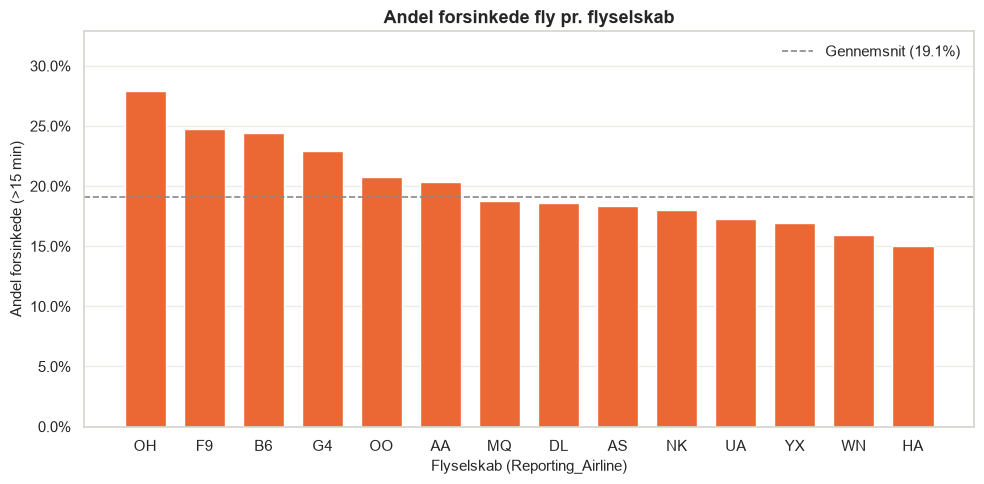

In [64]:
rate_airline = delay_rate("Reporting_Airline").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rate_airline.index, rate_airline.values, color=COLOR_DELAYED, width=0.7)
add_reference(ax)

ax.set_title("Andel forsinkede fly pr. flyselskab")
ax.set_xlabel("Flyselskab (Reporting_Airline)")
ax.set_ylabel("Andel forsinkede (>15 min)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Opsummering:** Der er stor forskel mellem flyselskaberne. **OH** (PSA Airlines) ligger højest med ca. 28 % forsinkede, fulgt af **F9** (Frontier) og **B6** (JetBlue) på omkring 25 %. **HA** (Hawaiian) og **WN** (Southwest) ligger lavest med ca. 15–16 %. Spændet er næsten 13 procentpoint, så flyselskab er en relevant feature.

### 4.3 Andel forsinkede pr. afgangstime

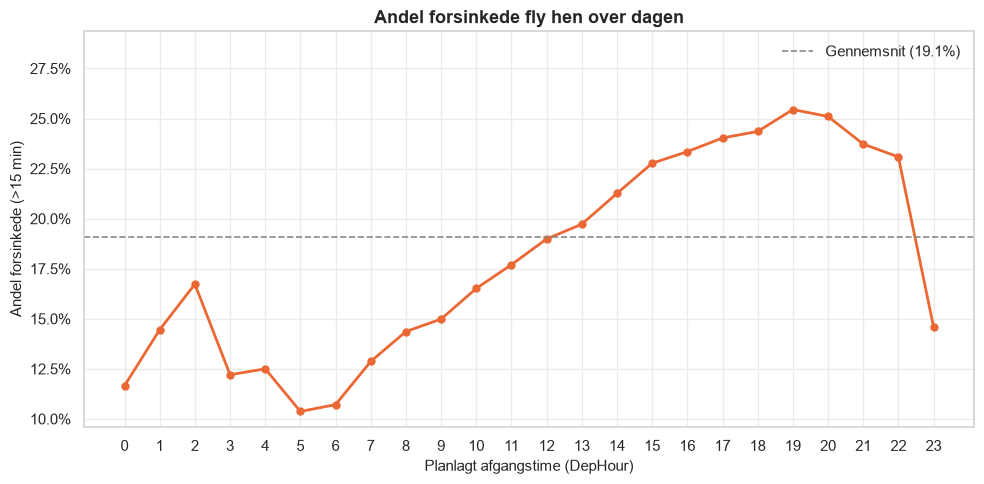

In [65]:
rate_hour = delay_rate("DepHour")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rate_hour.index, rate_hour.values, color=COLOR_DELAYED,
        linewidth=2, marker="o", markersize=5)
add_reference(ax)

ax.set_title("Andel forsinkede fly hen over dagen")
ax.set_xlabel("Planlagt afgangstime (DepHour)")
ax.set_ylabel("Andel forsinkede (>15 min)")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

**Opsummering:** Det er det tydeligste mønster i dataen. Morgenfly kl. 5–6 har de færreste forsinkelser (ca. 10–11 %). Derefter stiger andelen jævnt hen over dagen til en top omkring kl. 19–20 (ca. 25 %). Forsinkelser forplanter sig nemlig gennem dagen, fordi det samme fly flyver flere ture, og én forsinkelse rammer de næste. Timerne mellem kl. 0 og 4 har meget få flyvninger, så tallene der er mere tilfældige. `DepHour` ser ud til at være en stærk feature.

### 4.4 Andel forsinkede pr. ugedag

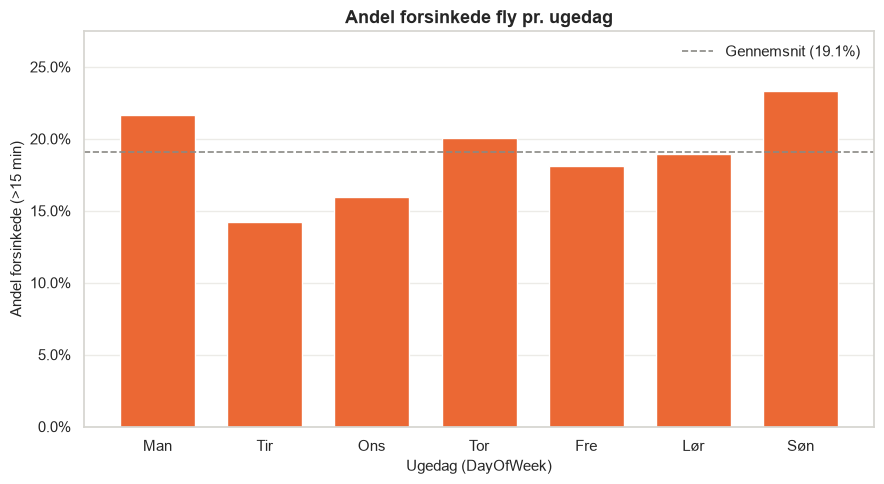

In [66]:
WEEKDAYS = {1: "Man", 2: "Tir", 3: "Ons", 4: "Tor", 5: "Fre", 6: "Lør", 7: "Søn"}

rate_weekday = delay_rate("DayOfWeek").rename(index=WEEKDAYS)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(rate_weekday.index, rate_weekday.values, color=COLOR_DELAYED, width=0.7)
add_reference(ax)

ax.set_title("Andel forsinkede fly pr. ugedag")
ax.set_xlabel("Ugedag (DayOfWeek)")
ax.set_ylabel("Andel forsinkede (>15 min)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Opsummering:** **Søndag** (ca. 23 %) og **mandag** (ca. 22 %) har flest forsinkelser, mens **tirsdag** (ca. 14 %) har færrest. Med kun tre måneders data er der dog kun ca. 13 af hver ugedag, så enkelte dage med dårligt vejr kan trække en ugedag meget op. Mønsteret skal derfor tages med forbehold.

### 4.5 Andel forsinkede pr. måned

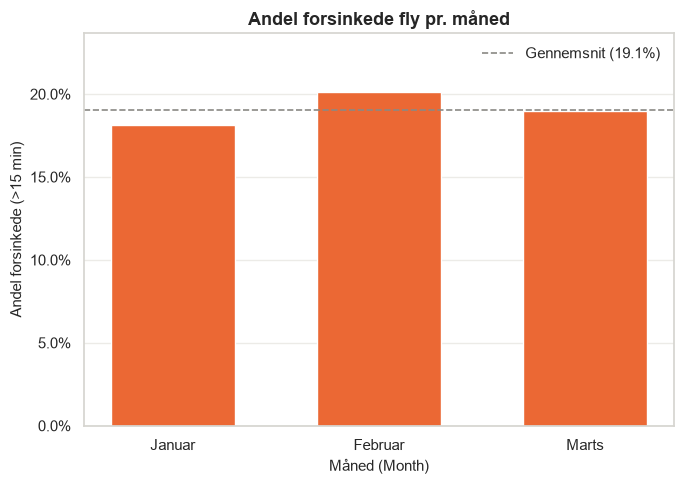

In [67]:
MONTHS = {1: "Januar", 2: "Februar", 3: "Marts"}

rate_month = delay_rate("Month").rename(index=MONTHS)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(rate_month.index, rate_month.values, color=COLOR_DELAYED, width=0.6)
add_reference(ax)

ax.set_title("Andel forsinkede fly pr. måned")
ax.set_xlabel("Måned (Month)")
ax.set_ylabel("Andel forsinkede (>15 min)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

**Opsummering:** Forskellen mellem månederne er lille. Februar ligger højest med ca. 20 % og januar lavest med ca. 18 %. Med kun tre vintermåneder kan vi ikke se sæsonmønstre (fx sommer- og juletrafik), så `Month` bliver sandsynligvis en svag feature i denne version. Den bliver mere nyttig, hvis vi senere udvider til et helt år.

### 4.6 Fordeling af distance: forsinkede vs. rettidige

Der er ca. 4 gange flere rettidige end forsinkede fly. Vi bruger derfor `stat="density"`, så vi sammenligner **formen** på de to fordelinger og ikke antallet.

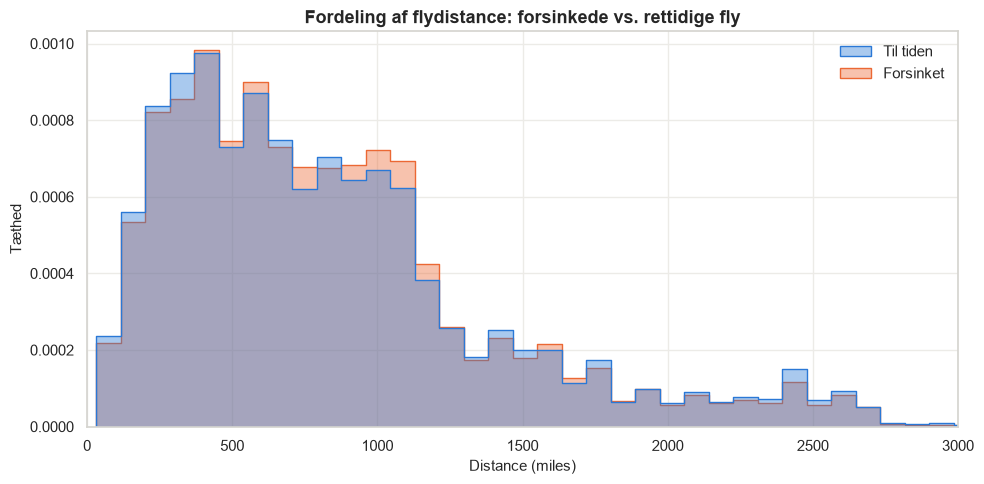

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=df.assign(Status=df["Delayed"].map({0: "Til tiden", 1: "Forsinket"})),
    x="Distance",
    hue="Status",
    hue_order=["Til tiden", "Forsinket"],
    palette={"Til tiden": COLOR_ONTIME, "Forsinket": COLOR_DELAYED},
    bins=60,
    stat="density",
    common_norm=False,  # hver gruppe normaliseres for sig
    element="step",  # trappe-kontur gør de to fordelinger lettere at skelne
    alpha=0.4,
    ax=ax,
)

ax.set_title("Fordeling af flydistance: forsinkede vs. rettidige fly")
# Meget få flyvninger er over 3000 miles (fx Hawaii), så vi zoomer ind
ax.set_xlim(0, 3000)
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Tæthed")
ax.get_legend().set_title(None)
ax.get_legend().set_frame_on(False)
plt.tight_layout()
plt.show()

**Opsummering:** De to fordelinger er næsten identiske. Medianen er ca. 720 miles for begge grupper, og formen er stort set den samme. Distance alene siger altså meget lidt om, om et fly bliver forsinket. Den kan stadig bidrage i kombination med andre features (fx rute eller lufthavn), men vi skal ikke forvente meget af den.

### 4.7 Samlet konklusion på EDA

| Feature | Signal | Kommentar |
|---|---|---|
| `DepHour` | **Stærkt** | Stiger fra ca. 10 % om morgenen til ca. 25 % om aftenen |
| `Reporting_Airline` | **Stærkt** | Spænd på ca. 13 procentpoint mellem selskaberne |
| `DayOfWeek` / `IsWeekend` | Moderat | Søn/man højest, tirsdag lavest, men kun 3 måneders data |
| `Month` | Svagt | Kun 3 vintermåneder, meget lille forskel |
| `Distance` | Svagt | Næsten ens fordeling for forsinkede og rettidige |

Klasserne er skævt fordelt (ca. 81 % til tiden og 19 % forsinket). Det skal vi huske, når vi vælger model og evalueringsmetrik.

## Step 5: Modellering

Nu træner vi de første modeller til at forudsige, om et fly bliver forsinket (`Delayed = 1`) eller er til tiden (`Delayed = 0`).

### Hvorfor sammenligne flere modeller?

Der findes ikke én model, der altid er bedst. Hver algoritme har sine egne antagelser om, hvordan data ser ud:
- **Decision Tree** kan fange ikke-lineære mønstre og interaktioner (fx "sen afgang *og* bestemt flyselskab").
- **Logistic Regression** antager en lineær sammenhæng mellem features og log-odds for forsinkelse.
- **KNN** antager, at fly med lignende egenskaber opfører sig ens.

Ved at sammenligne dem på det samme test-set kan vi se, hvilken tilgang der passer bedst til vores data. Vi får samtidig en baseline at forbedre fra.

### Class imbalance: hvorfor accuracy ikke er nok

Fra Step 2 ved vi, at ca. **81 % af flyene er til tiden** og kun **19 % er forsinkede**. Det betyder, at en "dum" model, der *altid* siger "til tiden", får ca. 81 % accuracy uden at have lært noget. Accuracy alene kan derfor være meget misvisende.

Vi bruger derfor fire metrics:

| Metric | Spørgsmål den besvarer |
|---|---|
| **Accuracy** | Hvor stor en andel af alle forudsigelser er korrekte? |
| **Precision** | Når modellen siger "forsinket", hvor ofte har den så ret? |
| **Recall** | Hvor stor en andel af de faktisk forsinkede fly fanger modellen? |
| **F1-score** | Harmonisk gennemsnit af precision og recall. Er kun høj, hvis *begge* er høje |

For et forsinkelses-problem er **recall og F1** de vigtigste. Vi vil gerne fange de forsinkede fly, og det er netop dem, en model under class imbalance har tendens til at overse.

### 5.1 Load data og train/test split

- Vi splitter 80/20 med `random_state=42`, så resultatet kan genskabes.
- `stratify=y` sikrer, at train og test har den samme andel forsinkede (ca. 19 %). Ellers kan tilfældigheder skævvride evalueringen.

In [69]:
import time

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("model_ready_flights.csv")

# Features (X) og target (y)
X = df.drop(columns=["Delayed"])
y = df["Delayed"]

# 80/20 split; stratify bevarer andelen af forsinkede i begge sæt
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train (fuld): {X_train_full.shape[0]:,} rækker")
print(f"Test:         {X_test.shape[0]:,} rækker")
print(f"Andel forsinkede i train: {y_train_full.mean():.1%}, test: {y_test.mean():.1%}")

Train (fuld): 1,288,836 rækker
Test:         322,210 rækker
Andel forsinkede i train: 19.1%, test: 19.1%


### 5.2 Sample træningsdata ned til 200.000 rækker

KNN gemmer hele træningssættet og sammenligner hvert test-fly med *alle* træningsfly. Med ca. 1,3 mio. træningsrækker og 322.000 testrækker ville det tage meget lang tid.

Vi sampler derfor træningsdata ned til **200.000 rækker**. For at sammenligningen er fair, træner vi **alle tre modeller på det samme sample**. **Test-sættet beholdes i fuld størrelse**, så evalueringen er så præcis som muligt.

In [70]:
TRAIN_SAMPLE_SIZE = 200_000

# Tilfældigt sample af træningsdata (samme sample bruges til alle modeller)
X_train = X_train_full.sample(n=TRAIN_SAMPLE_SIZE, random_state=42)
y_train = y_train_full.loc[X_train.index]

print(f"Train (sample): {X_train.shape[0]:,} rækker, andel forsinkede: {y_train.mean():.1%}")

Train (sample): 200,000 rækker, andel forsinkede: 19.1%


### 5.3 Evaluerings-funktion

For at undgå gentaget kode laver vi én funktion, der gør følgende for en model:
1. træner den
2. laver forudsigelser på test-sættet
3. printer accuracy, precision, recall og F1
4. viser confusion matrix som heatmap

**Sådan læses en confusion matrix:**

|  | Forudsagt: Til tiden | Forudsagt: Forsinket |
|---|---|---|
| **Faktisk: Til tiden** | True Negative (korrekt) | False Positive (falsk alarm) |
| **Faktisk: Forsinket** | False Negative (overset forsinkelse) | True Positive (fanget forsinkelse) |

En god model har høje tal på diagonalen, især nederst til højre.

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

LABELS = ["Til tiden", "Forsinket"]
results = []  # samler metrics for alle modeller til sammenligningstabellen


def evaluate_model(name, model):
    """Træn model, print metrics og vis confusion matrix. Gemmer metrics i `results`."""
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        # zero_division=0: hvis modellen aldrig forudsiger "forsinket", er precision 0
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Tid (s)": elapsed,
    }
    results.append(metrics)

    print(f"=== {name} ===  (træning + forudsigelse: {elapsed:.1f} s)")
    for key in ["Accuracy", "Precision", "Recall", "F1-score"]:
        print(f"{key:<10} {metrics[key]:.4f}")

    # Confusion matrix som heatmap
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"Confusion matrix: {name}")
    ax.set_xlabel("Forudsagt")
    ax.set_ylabel("Faktisk")
    plt.tight_layout()
    plt.show()

### 5.4 Decision Tree

Et **beslutningstræ** stiller en række ja/nej-spørgsmål om features (fx *"Er DepHour > 15?"*, *"Er flyselskabet OH?"*) og ender i et blad, der giver en forudsigelse. Træet vælger selv de spørgsmål, der bedst adskiller forsinkede fra rettidige fly.

- **Fordele:** let at fortolke, kræver ingen skalering, fanger ikke-lineære mønstre.
- **Ulemper:** overfitter let. Derfor begrænser vi dybden med `max_depth=10`.

=== Decision Tree ===  (træning + forudsigelse: 0.3 s)
Accuracy   0.8072
Precision  0.3826
Recall     0.0186
F1-score   0.0355


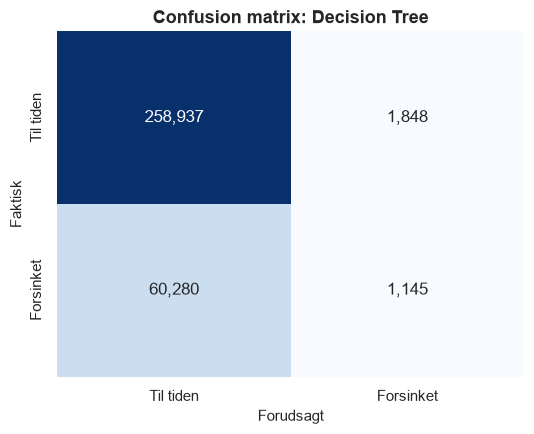

In [72]:
from sklearn.tree import DecisionTreeClassifier

evaluate_model("Decision Tree", DecisionTreeClassifier(max_depth=10, random_state=42))

### 5.5 Logistic Regression

**Logistisk regression** beregner en vægtet sum af features og sender den gennem en sigmoid-funktion, der giver en sandsynlighed mellem 0 og 1 for forsinkelse. Er sandsynligheden over 0,5, forudsiges "forsinket".

- **Fordele:** hurtig, stabil og fortolkelig (hver feature får en koefficient).
- **Ulemper:** kan kun fange lineære sammenhænge. Fx kan den ikke af sig selv fange, at forsinkelser topper kl. 19–20 og falder igen kl. 23.

**Skalering:** Features har meget forskellige skalaer (`Distance` op til ca. 5000, dummies 0/1). Vi bruger derfor `StandardScaler` i en pipeline, så alle features får middelværdi 0 og standardafvigelse 1. Det hjælper optimeringen med at konvergere.

=== Logistic Regression ===  (træning + forudsigelse: 0.1 s)
Accuracy   0.8094
Precision  0.0000
Recall     0.0000
F1-score   0.0000


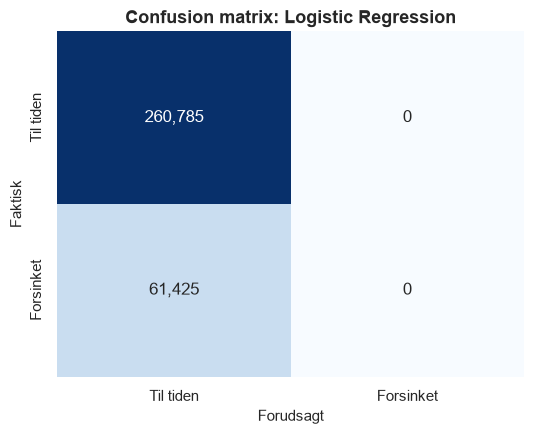

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

evaluate_model(
    "Logistic Regression",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
)

### 5.6 K-Nearest Neighbors (KNN)

**KNN** lærer ikke en egentlig model. Den gemmer bare træningsdata. For at forudsige et nyt fly finder den de **5 mest lignende fly** (`n_neighbors=5`) i træningsdata og lader dem "stemme". Er flest af dem forsinkede, forudsiges "forsinket".

- **Fordele:** simpel, ingen antagelser om datas form.
- **Ulemper:** langsom ved forudsigelse, fordi den skal sammenligne med alle træningsrækker. Den er også følsom over for skalering.

**Skalering er afgørende her:** KNN måler afstand mellem fly. Uden skalering ville `Distance` (hundreder til tusinder af miles) fuldstændig dominere over fx `IsWeekend` (0/1). Vi bruger derfor igen `StandardScaler`. `n_jobs=-1` bruger alle CPU-kerner.

*Denne celle tager typisk 20–60 sekunder.*

=== KNN (k=5) ===  (træning + forudsigelse: 27.3 s)
Accuracy   0.7781
Precision  0.2856
Recall     0.1093
F1-score   0.1581


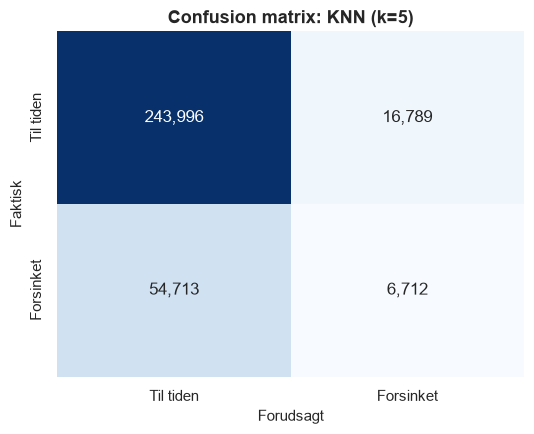

In [74]:
from sklearn.neighbors import KNeighborsClassifier

evaluate_model(
    "KNN (k=5)",
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
)

### 5.7 Sammenligning af modellerne

Vi samler alle metrics i én tabel. Som reference tilføjer vi en **baseline**, der *altid* forudsiger "til tiden". En model er kun interessant, hvis den slår baselinen på de metrics, der betyder noget (recall og F1). Det er ikke nok at slå den på accuracy.

In [75]:
# Baseline: forudsig altid "til tiden" (0)
baseline_pred = pd.Series(0, index=y_test.index)
baseline = {
    "Model": "Baseline (altid til tiden)",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": 0.0,
    "Recall": 0.0,
    "F1-score": 0.0,
    "Tid (s)": 0.0,
}

comparison = (
    pd.DataFrame([baseline] + results)
    .set_index("Model")
    .round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-score": 4, "Tid (s)": 1})
)
display(comparison)

,Accuracy,Precision,Recall,F1-score,Tid (s)
Model,,,,,
Baseline (altid til tiden),0.8094,0.0000,0.0000,0.0000,0.0
Decision Tree,0.8072,0.3826,0.0186,0.0355,0.3
Logistic Regression,0.8094,0.0000,0.0000,0.0000,0.1
KNN (k=5),0.7781,0.2856,0.1093,0.1581,27.3


### 5.8 Fortolkning

*(Tallene nedenfor er fra en testkørsel. Små afvigelser kan forekomme.)*

| Model | Accuracy | Recall | F1 |
|---|---|---|---|
| Baseline | ~0,81 | 0,00 | 0,00 |
| Decision Tree | ~0,81 | ~0,02 | ~0,04 |
| Logistic Regression | ~0,81 | 0,00 | 0,00 |
| KNN | ~0,78 | ~0,11 | ~0,16 |

**Accuracy-fælden i praksis:**
- **Logistic Regression** forudsiger *alle* fly som "til tiden". Den får ca. 81 % accuracy, præcis som baselinen, men har **ikke lært at finde en eneste forsinkelse** (recall = 0).
- **Decision Tree** har næsten samme accuracy som baselinen, men fanger kun ca. 2 % af de forsinkede fly.
- **KNN** har den *laveste* accuracy, men er den eneste model, der fanger en mærkbar andel af forsinkelserne. Den har derfor den bedste F1-score.

Hvis vi kun kiggede på accuracy, ville vi vælge den model, der er dårligst til det, vi faktisk vil opnå.

**Hvorfor sker det?** Med 81/19-fordeling og relativt svage features (se EDA) er modellernes sandsynlighed for "forsinket" sjældent over 0,5. Den nemmeste måde at minimere fejl på er derfor at gætte på majoritetsklassen.

**Næste skridt for at forbedre modellerne:**
1. **`class_weight="balanced"`**: straffer fejl på den sjældne klasse hårdere under træning (virker for Decision Tree og Logistic Regression).
2. **Justér beslutningsgrænsen**: brug fx 0,3 i stedet for 0,5 på `predict_proba`, så flere fly klassificeres som forsinkede.
3. **ROC-AUC / PR-AUC**: evaluér modellernes evne til at *rangere* fly efter risiko, uafhængigt af én bestemt grænse.
4. **Flere features**: `Origin`/`Dest` (via target encoding), vejrdata eller forsinkelse på det forrige fly.

## Step 6: Forbedrede modeller

I Step 5 så vi, at modellerne næsten aldrig forudsagde "forsinket". De lærte, at det bedst kan betale sig at gætte på majoritetsklassen. I dette step forsøger vi at rette op på det.

### Hvad gør `class_weight="balanced"`?

Når en model trænes, prøver den at minimere en samlet fejl (*loss*). Som standard tæller alle fejl lige meget. Med 81 % rettidige fly er den billigste strategi derfor at sige "til tiden" til næsten alt, fordi fejlene på de 19 % forsinkede fly kun udgør en lille del af den samlede fejl.

`class_weight="balanced"` giver hver klasse en vægt, der er omvendt proportional med dens hyppighed:

$$w_k = \frac{n_{\text{samples}}}{n_{\text{classes}} \cdot n_k}$$

Med vores fordeling giver det cirka:
- **Til tiden (81 %):** vægt ≈ 0,62
- **Forsinket (19 %):** vægt ≈ 2,6

En fejl på et forsinket fly **straffes altså ca. 4 gange hårdere** end en fejl på et rettidigt fly. Dermed tæller de to klasser *samlet set* lige meget i træningen, og modellen kan ikke længere "snyde" ved at ignorere minoritetsklassen.

**Forventet effekt:** recall stiger markant (vi fanger flere forsinkelser), precision falder (flere falske alarmer), og accuracy falder. Det er en bevidst afvejning. F1 og ROC-AUC fortæller os, om den samlede model er blevet bedre.

**KNN** har ingen `class_weight`-parameter, fordi den ikke minimerer en loss-funktion. Den stemmer bare blandt naboerne. Vi træner den igen på samme sample som før, så den kan indgå i ROC-sammenligningen.

### 6.1 Hjælpefunktion til de forbedrede modeller

Funktionen ligner den fra Step 5, men gemmer også modellens **sandsynligheder** (`predict_proba`), som vi skal bruge til ROC-kurverne. Forudsigelsen laves ud fra sandsynligheden med grænsen 0,5, præcis som `predict()` gør. På den måde skal KNN kun beregne naboer én gang.

Den bruger `X_train`, `y_train`, `X_test`, `y_test`, `results` og `LABELS` fra Step 5, så Step 5 skal være kørt først.

In [76]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve

improved_results = []  # metrics for de forbedrede modeller
probas = {}            # sandsynligheder på test-sættet til ROC-kurver


def evaluate_improved(name, model):
    """Træn model, print metrics, vis confusion matrix og gem sandsynligheder til ROC."""
    start = time.time()
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]  # sandsynlighed for "forsinket"
    y_pred = (y_proba >= 0.5).astype(int)        # samme grænse som predict()
    elapsed = time.time() - start

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Tid (s)": elapsed,
    }
    improved_results.append(metrics)
    probas[name] = y_proba

    print(f"=== {name} ===  (træning + forudsigelse: {elapsed:.1f} s)")
    for key in ["Accuracy", "Precision", "Recall", "F1-score"]:
        print(f"{key:<10} {metrics[key]:.4f}")

    # Confusion matrix som heatmap (samme stil som Step 5)
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"Confusion matrix: {name}")
    ax.set_xlabel("Forudsagt")
    ax.set_ylabel("Faktisk")
    plt.tight_layout()
    plt.show()

### 6.2 Decision Tree: vælg den bedste `max_depth`

Vi prøver `max_depth` = 10, 15 og 20 med `class_weight="balanced"`:
- **Et dybere træ** kan lære mere detaljerede mønstre, men risikerer at overfitte (lære støj i træningsdata).
- **Et fladere træ** generaliserer bedre, men kan overse mønstre.

**Vigtigt: vi vælger ikke dybden ud fra test-sættet.** Hvis vi tunede på test-sættet, ville test-resultatet blive for optimistisk, fordi vi så indirekte havde "trænet" på det. I stedet laver vi et **validation-sæt** af 100.000 rækker fra den del af træningsdata, som *ikke* kom med i vores 200k-sample. Test-sættet forbliver urørt til den endelige evaluering.

In [77]:
from sklearn.tree import DecisionTreeClassifier

# Validation-sæt fra de træningsrækker der ikke er i 200k-samplet (ingen overlap med train eller test)
X_val = X_train_full.drop(X_train.index).sample(n=100_000, random_state=42)
y_val = y_train_full.loc[X_val.index]

depth_scores = []
for depth in [10, 15, 20]:
    tree = DecisionTreeClassifier(max_depth=depth, class_weight="balanced", random_state=42)
    tree.fit(X_train, y_train)
    y_val_pred = tree.predict(X_val)
    depth_scores.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1-score": f1_score(y_val, y_val_pred),
    })

depth_scores = pd.DataFrame(depth_scores).set_index("max_depth").round(4)
BEST_DEPTH = depth_scores["F1-score"].idxmax()

print("Resultater på validation-sæt:")
display(depth_scores)
print(f"Bedste max_depth baseret på F1: {BEST_DEPTH}")

Resultater på validation-sæt:


,Accuracy,Precision,Recall,F1-score
max_depth,,,,
10,0.5621,0.2452,0.6188,0.3512
15,0.5638,0.2413,0.5958,0.3435
20,0.5844,0.2396,0.5384,0.3316


Bedste max_depth baseret på F1: 10


Nu træner vi det valgte træ og evaluerer det på test-sættet.

Et dybere træ gav **ikke** bedre F1. Dybere træer bliver bedre til at huske træningsdata, men ikke til at generalisere til nye fly. Det er et klassisk tegn på overfitting.

=== Decision Tree (balanced, depth=10) ===  (træning + forudsigelse: 0.4 s)
Accuracy   0.5641
Precision  0.2451
Recall     0.6185
F1-score   0.3511


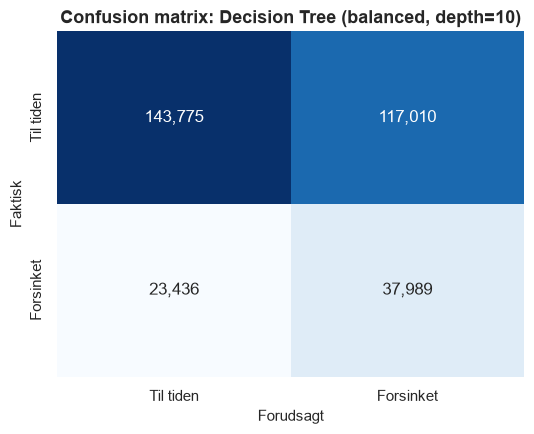

In [78]:
evaluate_improved(
    f"Decision Tree (balanced, depth={BEST_DEPTH})",
    DecisionTreeClassifier(max_depth=BEST_DEPTH, class_weight="balanced", random_state=42),
)

### 6.3 Logistic Regression (balanced)

Samme pipeline som i Step 5 (`StandardScaler` → `LogisticRegression`), nu med `class_weight="balanced"`.

=== Logistic Regression (balanced) ===  (træning + forudsigelse: 0.2 s)
Accuracy   0.5762
Precision  0.2422
Recall     0.5746
F1-score   0.3408


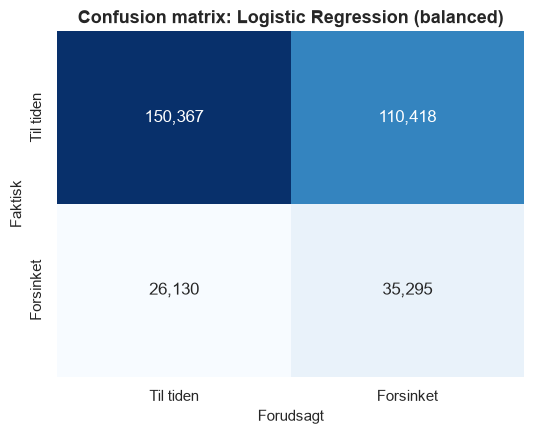

In [79]:
evaluate_improved(
    "Logistic Regression (balanced)",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
)

### 6.4 KNN (samme sample som før)

KNN kan ikke vægte klasser, så resultaterne ved grænsen 0,5 bliver de samme som i Step 5. Vi træner den igen for at få sandsynlighederne (andelen af de 5 naboer, der er forsinkede) til ROC-kurven.

*Denne celle tager typisk 20–60 sekunder.*

=== KNN (k=5) ===  (træning + forudsigelse: 27.9 s)
Accuracy   0.7781
Precision  0.2856
Recall     0.1093
F1-score   0.1581


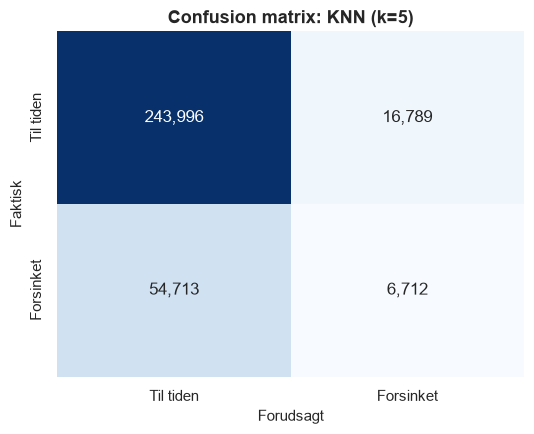

In [80]:
evaluate_improved(
    "KNN (k=5)",
    make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
)

### 6.5 Samlet sammenligning: originale vs. forbedrede modeller

In [81]:
all_results = pd.concat([
    pd.DataFrame([baseline]).assign(Version="Baseline"),
    pd.DataFrame(results).assign(Version="Original (Step 5)"),
    pd.DataFrame(improved_results).assign(Version="Forbedret (Step 6)"),
])

comparison_all = (
    all_results
    .set_index(["Version", "Model"])
    .round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-score": 4, "Tid (s)": 1})
)
display(comparison_all)

Accuracy  Precision  \
Version            Model                                                     
Baseline           Baseline (altid til tiden)            0.8094     0.0000   
Original (Step 5)  Decision Tree                         0.8072     0.3826   
                   Logistic Regression                   0.8094     0.0000   
                   KNN (k=5)                             0.7781     0.2856   
Forbedret (Step 6) Decision Tree (balanced, depth=10)    0.5641     0.2451   
                   Logistic Regression (balanced)        0.5762     0.2422   
                   KNN (k=5)                             0.7781     0.2856   

                                                       Recall  F1-score  \
Version            Model                                                  
Baseline           Baseline (altid til tiden)          0.0000    0.0000   
Original (Step 5)  Decision Tree                       0.0186    0.0355   
                   Logistic Regression                 0.0000    0.0000   
                   KNN (k=5)                           0.1093    0.1581   
Forbedret (Step 6) Decision Tree (balanced, depth=10)  0.6185    0.3511   
                   Logistic Regression (balanced)      0.5746    0.3408   
                   KNN (k=5)                           0.1093    0.1581   

                                                       Tid (s)  
Version            Model                                        
Baseline           Baseline (altid til tiden)              0.0  
Original (Step 5)  Decision Tree                           0.3  
                   Logistic Regression                     0.1  
                   KNN (k=5)                              27.3  
Forbedret (Step 6) Decision Tree (balanced, depth=10)      0.4  
                   Logistic Regression (balanced)          0.2  
                   KNN (k=5)                              27.9

### 6.6 ROC-kurver

En **ROC-kurve** viser, hvordan modellen klarer sig ved *alle* mulige beslutningsgrænser og ikke kun ved 0,5:
- **x-aksen (False Positive Rate):** andelen af rettidige fly, der fejlagtigt forudsiges som forsinkede
- **y-aksen (True Positive Rate = recall):** andelen af forsinkede fly, der fanges

**AUC** (arealet under kurven) samler det i ét tal:
- **0,5** = tilfældigt gæt (den stiplede diagonal)
- **1,0** = perfekt adskillelse

AUC er uafhængig af beslutningsgrænsen og af class imbalance. Den måler, hvor godt modellen **rangerer** fly efter risiko. Det gør den til en god metric at sammenligne modeller på.

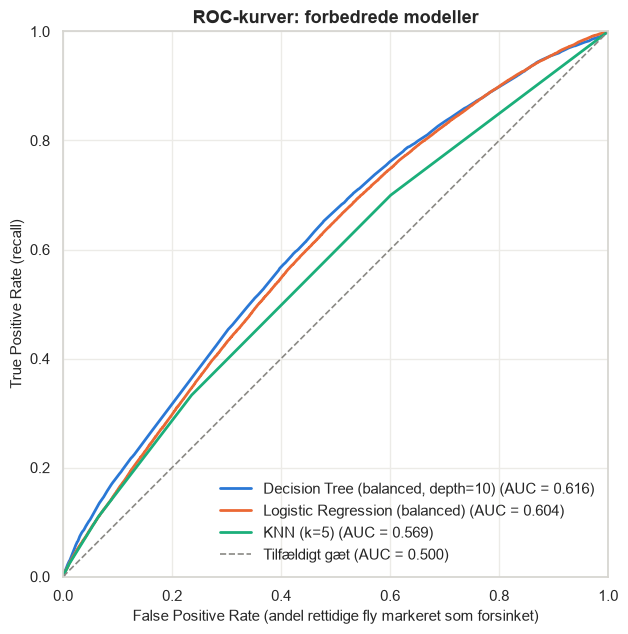

In [82]:
# Konsistente modelfarver (samme rækkefølge som modellerne er trænet)
ROC_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]  # blå, orange, aqua

fig, ax = plt.subplots(figsize=(7.5, 6.5))

for (name, y_proba), color in zip(probas.items(), ROC_COLORS):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

# Diagonal = tilfældigt gæt
ax.plot([0, 1], [0, 1], color="#8a8984", linestyle="--", linewidth=1.2,
        label="Tilfældigt gæt (AUC = 0.500)")

ax.set_title("ROC-kurver: forbedrede modeller")
ax.set_xlabel("False Positive Rate (andel rettidige fly markeret som forsinket)")
ax.set_ylabel("True Positive Rate (recall)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### 6.7 Fortolkning

*(Tallene nedenfor er fra en testkørsel. Små afvigelser kan forekomme.)*

| Model | Recall (før → efter) | F1 (før → efter) | ROC-AUC |
|---|---|---|---|
| Decision Tree (depth=10) | 0,02 → **0,62** | 0,04 → **0,35** | ~0,62 |
| Logistic Regression | 0,00 → **0,57** | 0,00 → **0,34** | ~0,60 |
| KNN (k=5) | 0,11 → 0,11 | 0,16 → 0,16 | ~0,57 |

**`class_weight="balanced"` virker:**
- Decision Tree og Logistic Regression går fra at fange næsten ingen forsinkelser til at fange **ca. 60 %** af dem.
- F1-scoren stiger fra næsten 0 til ca. 0,35.
- Prisen er lavere accuracy (fra ca. 81 % til ca. 57 %) og lavere precision (ca. 0,24), fordi modellerne nu laver mange falske alarmer. For et varslingssystem er det ofte en fornuftig afvejning, fordi det er bedre at advare om en forsinkelse, der ikke kommer, end at overse en, der gør.

**Dybden på træet:** `max_depth=10` gav den bedste F1 på validation-sættet. Dybere træer (15, 20) overfitter og generaliserer dårligere.

**ROC-AUC:** Alle modeller ligger kun ca. 0,57–0,62, altså ikke langt over tilfældigt gæt (0,5). Det bekræfter det, EDA'en antydede: **vores nuværende features har begrænset forklaringskraft**. `class_weight` ændrer, *hvor* modellen sætter grænsen, men den kan ikke skabe information, der ikke er i data.

**Næste skridt:** Den største forbedring kommer sandsynligvis fra **bedre features**, ikke fra flere modeltyper. Oplagte kandidater er:
- `Origin`/`Dest` med target encoding
- travlhed pr. lufthavn og time
- vejrdata
- forsinkelse på flyets forrige tur

## Step 7: Feature Engineering v2: Lufthavns-features

Step 6 viste, at modellerne er begrænset af **features**, ikke af valget af algoritme (ROC-AUC ca. 0,60–0,62). I Step 3 droppede vi `Origin` og `Dest`, fordi de har over 300 kategorier hver. Men lufthavnen er sandsynligvis en vigtig faktor. Travle hubs og lufthavne med dårligt vintervejr har typisk flere forsinkelser.

I dette step genindfører vi den information med **target encoding**.

### Hvad er target encoding?

I stedet for at lave én dummy-kolonne pr. kategori (one-hot) erstatter vi hver kategori med **gennemsnittet af target-variablen** for den kategori:

| Origin | Antal fly (train) | Heraf forsinket | `Origin_delay_rate` |
|---|---|---|---|
| ORD | 20.000 | 5.000 | 0,25 |
| SEA | 15.000 | 2.250 | 0,15 |

Så bliver 333 lufthavne til **én numerisk kolonne**, som modellen kan bruge direkte, og som tilmed er ordnet efter risiko. Det samme gør vi for kombinationen af **afgangstime × flyselskab** (`DepHour_airline_delay_rate`). Den fanger fx, at ét selskab kan være særligt forsinket om aftenen.

### Hvorfor kun på træningsdata? (Data leakage)

Target encoding bruger selve target-variablen til at lave features, og det gør den farlig. Kapoor & Narayanan (2023, *"Leakage and the reproducibility crisis in machine-learning-based science"*) viser, at **data leakage** er en af de mest udbredte fejl i ML-baseret forskning. En af de typiske former er netop **preprocessing på trænings- og testdata samlet**.

Hvis vi beregnede forsinkelsesraten pr. lufthavn på *hele* datasættet, ville test-flyenes egne udfald indgå i deres features. Modellen ville så indirekte "se svaret" for test-sættet, og vi ville få for optimistiske resultater, som ikke holder på nye, fremtidige flyvninger. I virkeligheden kender vi jo kun historiske data, når vi skal forudsige.

**Vi tager to forholdsregler:**

1. **Encodingen beregnes kun på træningsdata** og mappes derefter over på test-sættet. Kategorier, der ikke findes i træningsdata, får den globale gennemsnitsrate.
2. **Encodingen beregnes på andre træningsrækker end dem, modellen trænes på.** Hvis et fly selv indgår i gennemsnittet for sin lufthavn, lækker dets eget udfald ind i dets feature. Det gælder især for små lufthavne og sjældne time × selskab-kombinationer. Vi bruger derfor de ca. 1,09 mio. træningsrækker, der *ikke* er i vores 200k-sample, til at beregne encodingen. Modellen trænes på de 200k.

Derudover bruger vi **smoothing**. Kategorier med få fly trækkes mod det globale gennemsnit, så en lufthavn med 3 fly, hvoraf 2 var forsinkede, ikke får en rate på 67 %.

### 7.1 Load data og basis-features

Vi loader `cleaned_flights.csv`, som stadig har `Origin` og `Dest`, og laver de samme features som i Step 3.

In [83]:
df = pd.read_csv("cleaned_flights.csv")

# Samme basis-features som i Step 3
df["DepHour"] = df["CRSDepTime"] // 100
df["IsWeekend"] = df["DayOfWeek"].isin([6, 7]).astype(int)

print(f"Loaded: {df.shape[0]:,} rækker, {df.shape[1]} kolonner")

Loaded: 1,611,046 rækker, 11 kolonner


### 7.2 Train/test split: samme split som Step 5

Vi bruger præcis samme split-parametre (80/20, `random_state=42`, `stratify`). Rækkefølgen i `cleaned_flights.csv` og `model_ready_flights.csv` er den samme, så vi får **nøjagtig det samme test-sæt**. Resultaterne kan derfor sammenlignes direkte med Step 6. Det tjekker vi med en `assert`.

Derefter deler vi træningsdata i to dele:
- **Model-træning:** samme 200.000 rækker som i Step 5–6
- **Encoding:** de resterende ca. 1,09 mio. træningsrækker, som kun bruges til at beregne forsinkelsesrater

In [84]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["Delayed"]
)

# Tjek: samme test-sæt som i Step 5 og 6
assert test_df.index.equals(X_test.index), "Test-sættet matcher ikke Step 5"

# Samme 200k rækker til modeltræning som i Step 5-6
fit_df = train_df.loc[X_train.index]

# Resten af træningsdata bruges KUN til at beregne target encoding
encode_df = train_df.drop(fit_df.index)

print(f"Model-træning: {len(fit_df):,} rækker")
print(f"Encoding:      {len(encode_df):,} rækker")
print(f"Test:          {len(test_df):,} rækker")

Model-træning: 200,000 rækker
Encoding:      1,088,836 rækker
Test:          322,210 rækker


### 7.3 Target encoding

`target_encode` beregner den udglattede forsinkelsesrate pr. kategori på encoding-data:

$$\text{rate} = \frac{\text{antal forsinkede} + m \cdot \text{global rate}}{\text{antal fly} + m}$$

Med `m = 20` får en kategori med få fly en rate tæt på det globale gennemsnit. En lufthavn med tusindvis af fly får sin egen rate.

In [85]:
SMOOTHING = 20                              # m: "pseudo-fly" med global rate
GLOBAL_RATE = encode_df["Delayed"].mean()   # fallback for ukendte kategorier


def target_encode(keys):
    """Udglattet forsinkelsesrate pr. kategori, KUN beregnet på encode_df."""
    stats = encode_df.groupby(keys)["Delayed"].agg(["sum", "count"])
    return (stats["sum"] + SMOOTHING * GLOBAL_RATE) / (stats["count"] + SMOOTHING)


# Beregn encodings (kun på træningsdata)
origin_rates = target_encode("Origin")
dest_rates = target_encode("Dest")
hour_airline_rates = target_encode(["DepHour", "Reporting_Airline"]).rename("DepHour_airline_delay_rate")


def add_encoded_features(data):
    """Map de færdigberegnede rater over på et datasæt (train eller test)."""
    data = data.copy()
    data["Origin_delay_rate"] = data["Origin"].map(origin_rates).fillna(GLOBAL_RATE)
    data["Dest_delay_rate"] = data["Dest"].map(dest_rates).fillna(GLOBAL_RATE)
    data = data.join(hour_airline_rates, on=["DepHour", "Reporting_Airline"])
    data["DepHour_airline_delay_rate"] = data["DepHour_airline_delay_rate"].fillna(GLOBAL_RATE)
    return data


fit_enc = add_encoded_features(fit_df)
test_enc = add_encoded_features(test_df)

print(f"Global forsinkelsesrate: {GLOBAL_RATE:.1%}")
print(f"Lufthavne med rate: {len(origin_rates)} (Origin), {len(dest_rates)} (Dest)")
print("\nMest forsinkede afgangslufthavne (min. 1000 fly):")
origin_counts = encode_df["Origin"].value_counts()
display(origin_rates[origin_counts[origin_counts >= 1000].index].sort_values(ascending=False).head(5).round(3))

Global forsinkelsesrate: 19.1%
Lufthavne med rate: 333 (Origin), 333 (Dest)

Mest forsinkede afgangslufthavne (min. 1000 fly):


Origin
ASE    0.347
JAC    0.285
EYW    0.278
EGE    0.277
SYR    0.263
dtype: float64

### 7.4 One-hot encoding og oprydning

Flyselskabet one-hot encodes som i Step 3. Derefter dropper vi de rå kolonner, som nu er erstattet af numeriske features. `ArrDelay` blev allerede fjernet i Step 2, så den ignoreres, hvis den ikke findes.

One-hot laves separat på train og test, så vi bruger `reindex` til at sikre, at test-sættet har præcis de samme kolonner i samme rækkefølge som train.

In [86]:
DROP_COLS = ["FlightDate", "Origin", "Dest", "CRSDepTime", "ArrDelay"]


def finalize_features(data):
    """One-hot encode flyselskab og drop rå kolonner."""
    data = pd.get_dummies(data, columns=["Reporting_Airline"], drop_first=True, dtype=int)
    return data.drop(columns=DROP_COLS, errors="ignore")  # ArrDelay er allerede væk


fit_final = finalize_features(fit_enc)
test_final = finalize_features(test_enc).reindex(columns=fit_final.columns, fill_value=0)

X_train_v2, y_train_v2 = fit_final.drop(columns=["Delayed"]), fit_final["Delayed"]
X_test_v2, y_test_v2 = test_final.drop(columns=["Delayed"]), test_final["Delayed"]

print("Train:", X_train_v2.shape, " Test:", X_test_v2.shape)
print("Nye features:", ["Origin_delay_rate", "Dest_delay_rate", "DepHour_airline_delay_rate"])
display(X_train_v2.head())

Train: (200000, 21)  Test: (322210, 21)
Nye features: ['Origin_delay_rate', 'Dest_delay_rate', 'DepHour_airline_delay_rate']


,Month,DayOfWeek,Distance,DepHour,IsWeekend,Origin_delay_rate,Dest_delay_rate,DepHour_airline_delay_rate,Reporting_Airline_AS,Reporting_Airline_B6,...,Reporting_Airline_F9,Reporting_Airline_G4,Reporting_Airline_HA,Reporting_Airline_MQ,Reporting_Airline_NK,Reporting_Airline_OH,Reporting_Airline_OO,Reporting_Airline_UA,Reporting_Airline_WN,Reporting_Airline_YX
282876,1,6,1703.0,15,1,0.216478,0.183548,0.201467,0,0,...,0,0,0,0,0,0,0,0,1,0
610109,2,3,1121.0,6,0,0.198095,0.190717,0.112955,0,1,...,0,0,0,0,0,0,0,0,0,0
143972,1,3,935.0,15,0,0.153717,0.158042,0.228420,0,0,...,0,0,0,0,0,0,1,0,0,0
18356,1,5,632.0,14,0,0.216478,0.177488,0.234402,0,0,...,0,0,0,0,0,0,0,0,0,0
919535,2,3,1501.0,14,0,0.228862,0.163235,0.195379,0,0,...,0,0,0,0,0,0,0,0,0,0


### 7.5 Træn modellerne på de nye features

Samme to modeller som i Step 6, med `class_weight="balanced"` og `max_depth=10` for Decision Tree. Den eneste forskel er features, så en ændring i resultatet kan tilskrives de nye lufthavns-features.

=== Decision Tree v2 (balanced, depth=10) ===  (træning + forudsigelse: 0.7 s)
Accuracy   0.5839
Precision  0.2523
Recall     0.6023
F1-score   0.3556
ROC-AUC    0.6277


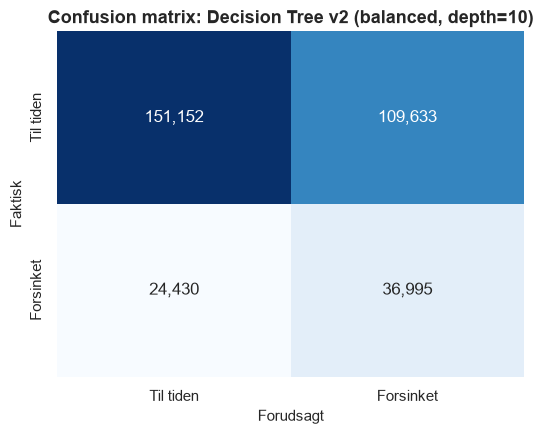

In [87]:
v2_results = []  # metrics for v2-modellerne
v2_probas = {}   # sandsynligheder til ROC-kurver


def evaluate_v2(name, model):
    """Træn på v2-features, print metrics og vis confusion matrix."""
    start = time.time()
    model.fit(X_train_v2, y_train_v2)
    y_proba = model.predict_proba(X_test_v2)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    elapsed = time.time() - start

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_v2, y_pred),
        "Precision": precision_score(y_test_v2, y_pred, zero_division=0),
        "Recall": recall_score(y_test_v2, y_pred),
        "F1-score": f1_score(y_test_v2, y_pred),
        "ROC-AUC": roc_auc_score(y_test_v2, y_proba),
        "Tid (s)": elapsed,
    }
    v2_results.append(metrics)
    v2_probas[name] = y_proba

    print(f"=== {name} ===  (træning + forudsigelse: {elapsed:.1f} s)")
    for key in ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]:
        print(f"{key:<10} {metrics[key]:.4f}")

    cm = confusion_matrix(y_test_v2, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f"Confusion matrix: {name}")
    ax.set_xlabel("Forudsagt")
    ax.set_ylabel("Faktisk")
    plt.tight_layout()
    plt.show()


evaluate_v2(
    "Decision Tree v2 (balanced, depth=10)",
    DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
)

=== Logistic Regression v2 (balanced) ===  (træning + forudsigelse: 0.2 s)
Accuracy   0.5886
Precision  0.2537
Recall     0.5965
F1-score   0.3560
ROC-AUC    0.6293


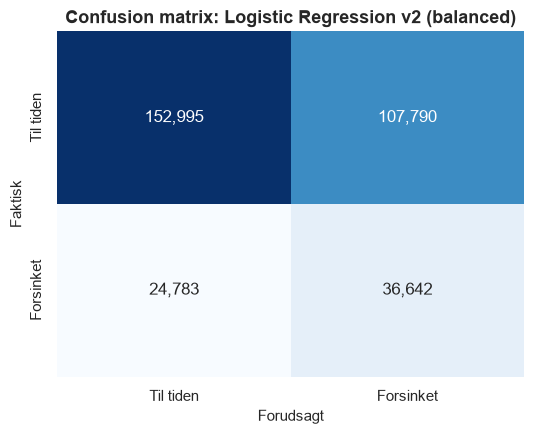

In [88]:
evaluate_v2(
    "Logistic Regression v2 (balanced)",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
)

### 7.6 Sammenligning med Step 6

Vi sammenligner med de to tilsvarende modeller fra Step 6. Det er samme model, samme træningsrækker og samme test-sæt, men uden lufthavns-features. ROC-AUC for Step 6-modellerne beregnes ud fra de gemte sandsynligheder.

In [89]:
# Step 6-modellerne vi sammenligner med (KNN er ikke med i v2)
step6_rows = []
for row in improved_results:
    if row["Model"] in probas and not row["Model"].startswith("KNN"):
        step6_rows.append({**row, "ROC-AUC": roc_auc_score(y_test, probas[row["Model"]])})

comparison_v2 = (
    pd.concat([
        pd.DataFrame(step6_rows).assign(Version="Step 6: uden lufthavns-features"),
        pd.DataFrame(v2_results).assign(Version="Step 7: med lufthavns-features"),
    ])
    .set_index(["Version", "Model"])
    [["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Tid (s)"]]
    .round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-score": 4, "ROC-AUC": 4, "Tid (s)": 1})
)
display(comparison_v2)

Accuracy  \
Version                         Model                                             
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)       0.5641   
                                Logistic Regression (balanced)           0.5762   
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)    0.5839   
                                Logistic Regression v2 (balanced)        0.5886   

                                                                       Precision  \
Version                         Model                                              
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)        0.2451   
                                Logistic Regression (balanced)            0.2422   
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)     0.2523   
                                Logistic Regression v2 (balanced)         0.2537   

                                                                       Recall  \
Version                         Model                                           
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)     0.6185   
                                Logistic Regression (balanced)         0.5746   
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)  0.6023   
                                Logistic Regression v2 (balanced)      0.5965   

                                                                       F1-score  \
Version                         Model                                             
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)       0.3511   
                                Logistic Regression (balanced)           0.3408   
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)    0.3556   
                                Logistic Regression v2 (balanced)        0.3560   

                                                                       ROC-AUC  \
Version                         Model                                            
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)      0.6155   
                                Logistic Regression (balanced)          0.6037   
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)   0.6277   
                                Logistic Regression v2 (balanced)       0.6293   

                                                                       Tid (s)  
Version                         Model                                           
Step 6: uden lufthavns-features Decision Tree (balanced, depth=10)         0.4  
                                Logistic Regression (balanced)             0.2  
Step 7: med lufthavns-features  Decision Tree v2 (balanced, depth=10)      0.7  
                                Logistic Regression v2 (balanced)          0.2

### 7.7 ROC-kurver: Step 6 vs. Step 7

Hver modeltype har sin egen farve. **Fuldt optrukket** er v2 (med lufthavns-features), og **stiplet** er Step 6-versionen. En kurve længere oppe mod venstre betyder en bedre model.

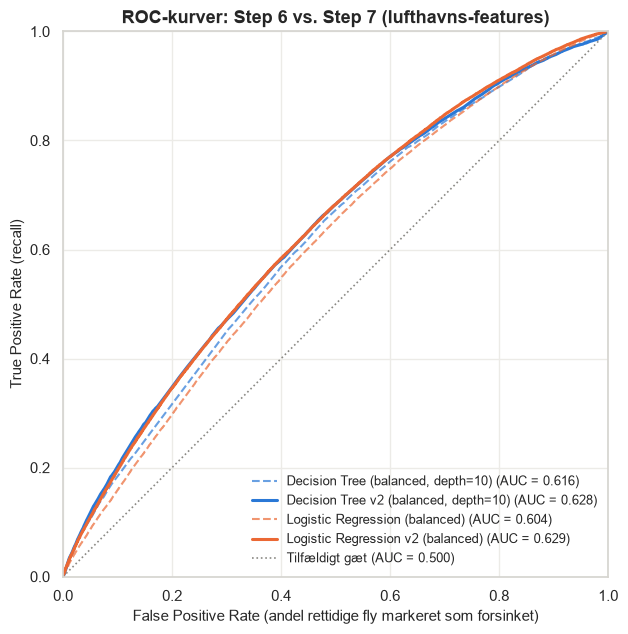

In [90]:
# Samme farve pr. modeltype; linjestil viser version
MODEL_COLORS = {"Decision Tree": "#2a78d6", "Logistic Regression": "#eb6834"}

fig, ax = plt.subplots(figsize=(7.5, 6.5))

for model_type, color in MODEL_COLORS.items():
    # Step 6 (stiplet)
    for name, y_proba in probas.items():
        if name.startswith(model_type):
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            ax.plot(fpr, tpr, color=color, linewidth=1.5, linestyle="--", alpha=0.7,
                    label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
    # Step 7 (fuldt optrukket)
    for name, y_proba in v2_probas.items():
        if name.startswith(model_type):
            fpr, tpr, _ = roc_curve(y_test_v2, y_proba)
            ax.plot(fpr, tpr, color=color, linewidth=2.2,
                    label=f"{name} (AUC = {roc_auc_score(y_test_v2, y_proba):.3f})")

ax.plot([0, 1], [0, 1], color="#8a8984", linestyle=":", linewidth=1.2,
        label="Tilfældigt gæt (AUC = 0.500)")

ax.set_title("ROC-kurver: Step 6 vs. Step 7 (lufthavns-features)")
ax.set_xlabel("False Positive Rate (andel rettidige fly markeret som forsinket)")
ax.set_ylabel("True Positive Rate (recall)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 7.8 Fortolkning

*(Tallene nedenfor er fra en testkørsel. Små afvigelser kan forekomme.)*

| Model | F1 (Step 6 → 7) | ROC-AUC (Step 6 → 7) |
|---|---|---|
| Decision Tree (balanced, depth=10) | 0,351 → **0,356** | 0,616 → **0,628** |
| Logistic Regression (balanced) | 0,341 → **0,356** | 0,604 → **0,629** |

**Lufthavnene med den højeste forsinkelsesrate** er især små bjerg- og skisportslufthavne: Aspen (ASE, ca. 35 %), Jackson Hole (JAC) og Eagle/Vail (EGE). Det giver god mening i vintermånederne med sne, korte landingsbaner og krævende indflyvninger. Den slags information kunne modellen ikke få fra de gamle features.

**Lufthavns-features hjælper, men kun lidt.**
- Begge modeller forbedres på både F1 og ROC-AUC. Logistic Regression får mest ud af det (+0,025 AUC), fordi target encoding omsætter kategorier til én lineær "risiko-skala", som en lineær model kan bruge direkte.
- Efter target encoding klarer de to modeller sig næsten lige godt. Det tyder på, at de fleste ikke-lineære mønstre, som træet fangede, nu ligger i de encodede features.

**Resultatet er troværdigt:** Encodingen er kun beregnet på træningsrækker, som hverken er test-data eller modellens egne træningsrækker. Forbedringen skyldes derfor ikke leakage. Havde vi beregnet raterne på hele datasættet, kunne resultatet have set bedre ud på papiret, men det ville ikke holde på nye flyvninger.

**Hvorfor ikke mere?** En ROC-AUC på ca. 0,63 er stadig beskeden. Features som lufthavn, tidspunkt og flyselskab beskriver *strukturelle* risici, men mange forsinkelser skyldes *dagsaktuelle* forhold, som vi ikke har data på:
- **vejr:** storme og snestorme rammer mange fly på samme dag
- **kaskade-forsinkelser:** var flyet forsinket på sin forrige tur?
- **trængsel:** hvor mange fly skal afgå fra lufthavnen i samme time?

Det er de oplagte næste features, hvis modellen skal forbedres markant.

## Step 8: Fairness-analyse

En samlet F1 på ca. 0,36 siger ikke noget om, hvordan modellen klarer sig for **forskellige grupper**. En model kan være god i gennemsnit, men systematisk dårligere for nogle grupper. I dette step undersøger vi, om modellens fejl er ligeligt fordelt på tværs af **flyselskaber**.

Det er relevant for to typer brugere af modellen:
1. **Passagerer**, som fx får en advarsel om forventet forsinkelse. Her er **recall** afgørende: hvor mange af de faktiske forsinkelser bliver de varslet om?
2. **En myndighed**, som kunne bruge modellen til at vurdere eller sanktionere flyselskaber. Her er **precision** og **falske alarmer** afgørende: bliver et selskab beskyldt for forsinkelser, der ikke sker?

### 8.1 Vælg den bedste model fra Step 7

Vi vælger modellen med højest F1 på test-sættet. Vi har allerede dens sandsynligheder i `v2_probas`, så vi behøver ikke træne igen.

In [91]:
# Bedste v2-model efter F1
best_v2 = max(v2_results, key=lambda r: r["F1-score"])
BEST_MODEL_NAME = best_v2["Model"]
print(f"Bedste model: {BEST_MODEL_NAME}  (F1 = {best_v2['F1-score']:.4f}, ROC-AUC = {best_v2['ROC-AUC']:.4f})")

# Forudsigelser på test-sættet + flyselskab pr. række
fair_df = pd.DataFrame({
    "Airline": test_df["Reporting_Airline"].values,
    "y_true": y_test_v2.values,
    "y_pred": (v2_probas[BEST_MODEL_NAME] >= 0.5).astype(int),
})
print(f"Test-sæt: {len(fair_df):,} flyvninger, {fair_df['Airline'].nunique()} flyselskaber")

Bedste model: Logistic Regression v2 (balanced)  (F1 = 0.3560, ROC-AUC = 0.6293)
Test-sæt: 322,210 flyvninger, 14 flyselskaber


### 8.2 Metrics pr. flyselskab

Ud over de fire standard-metrics beregner vi tre tal, der er vigtige for fairness:
- **Faktisk rate:** andelen af selskabets fly, der *faktisk* var forsinkede (base rate).
- **Forudsagt rate:** andelen af selskabets fly, som modellen *markerer* som forsinkede.
- **FPR (False Positive Rate):** andelen af selskabets *rettidige* fly, der fejlagtigt markeres som forsinkede.
- **Oversete forsinkelser:** antal faktisk forsinkede fly, som modellen ikke varslede (false negatives).

In [92]:
def group_metrics(group):
    """Beregn metrics for én gruppe (ét flyselskab)."""
    y_true, y_pred = group["y_true"], group["y_pred"]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return pd.Series({
        "Antal fly": len(group),
        "Faktisk rate": y_true.mean(),
        "Forudsagt rate": y_pred.mean(),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "FPR": fp / (fp + tn),
        "Oversete forsinkelser": fn,
    })


airline_metrics = (
    fair_df.groupby("Airline")[["y_true", "y_pred"]]
    .apply(group_metrics)
    .sort_values("F1-score", ascending=False)
)
COUNT_COLS = ["Antal fly", "Oversete forsinkelser"]
airline_metrics[COUNT_COLS] = airline_metrics[COUNT_COLS].astype(int)

# Samlet række til reference
overall = group_metrics(fair_df).rename("ALLE")
table = pd.concat([airline_metrics, overall.to_frame().T]).round(3)
table[COUNT_COLS] = table[COUNT_COLS].astype(int)
display(table)

print(f"Recall spænder fra {airline_metrics['Recall'].min():.1%} "
      f"({airline_metrics['Recall'].idxmin()}) til {airline_metrics['Recall'].max():.1%} "
      f"({airline_metrics['Recall'].idxmax()})")

,Antal fly,Faktisk rate,Forudsagt rate,Accuracy,Precision,Recall,F1-score,FPR,Oversete forsinkelser
OH,11651,0.279,0.733,0.455,0.318,0.837,0.461,0.693,530
G4,6376,0.238,0.628,0.508,0.298,0.787,0.433,0.579,324
B6,11099,0.241,0.667,0.479,0.290,0.801,0.426,0.624,532
F9,9840,0.245,0.730,0.427,0.275,0.820,0.411,0.701,434
AA,44483,0.204,0.543,0.530,0.255,0.680,0.371,0.508,2900
OO,38365,0.209,0.491,0.556,0.261,0.611,0.365,0.459,3124
DL,45458,0.187,0.461,0.570,0.237,0.583,0.337,0.433,3550
NK,10291,0.176,0.403,0.614,0.239,0.549,0.333,0.373,816
WN,64398,0.158,0.309,0.685,0.246,0.482,0.326,0.276,5263
MQ,12729,0.187,0.504,0.529,0.218,0.588,0.319,0.484,981


Recall spænder fra 38.2% (HA) til 83.7% (OH)


### 8.3 Recall og precision pr. flyselskab

Grouped bar chart sorteret efter recall. Den stiplede linje viser den samlede recall for hele test-sættet.

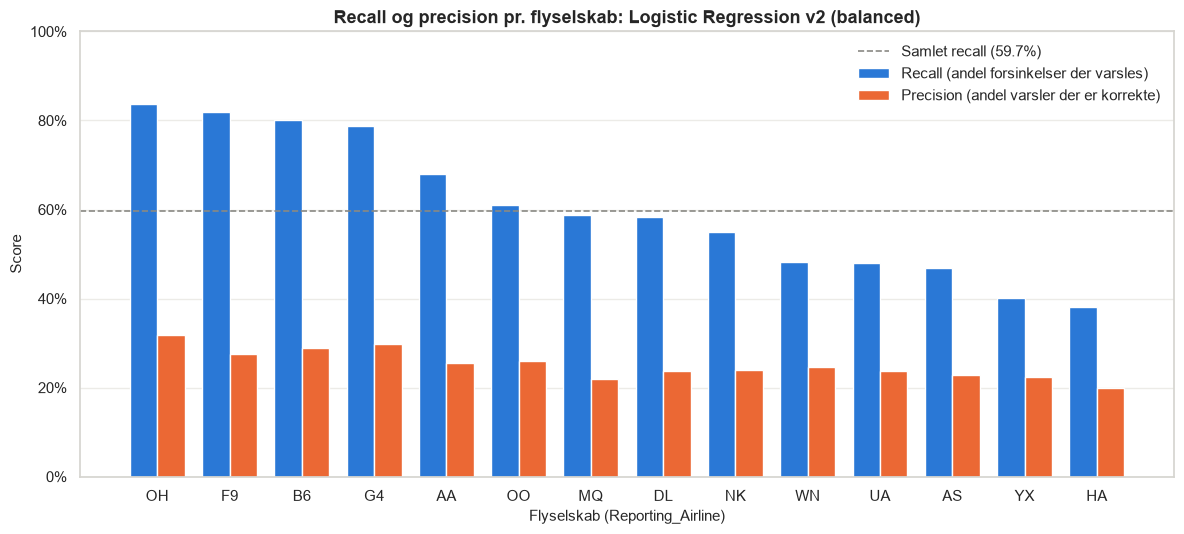

In [93]:
plot_df = airline_metrics.sort_values("Recall", ascending=False)
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x - width / 2, plot_df["Recall"], width, color="#2a78d6", label="Recall (andel forsinkelser der varsles)")
ax.bar(x + width / 2, plot_df["Precision"], width, color="#eb6834", label="Precision (andel varsler der er korrekte)")
ax.axhline(overall["Recall"], color="#8a8984", linestyle="--", linewidth=1.2,
           label=f"Samlet recall ({overall['Recall']:.1%})")

ax.set_title(f"Recall og precision pr. flyselskab: {BEST_MODEL_NAME}")
ax.set_xlabel("Flyselskab (Reporting_Airline)")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

### 8.4 Faktisk vs. forudsagt forsinkelsesrate

Dette plot viser, om modellen **overestimerer** forsinkelser for nogle selskaber mere end for andre. Det er vigtigt for diskussionen om sanktioner nedenfor.

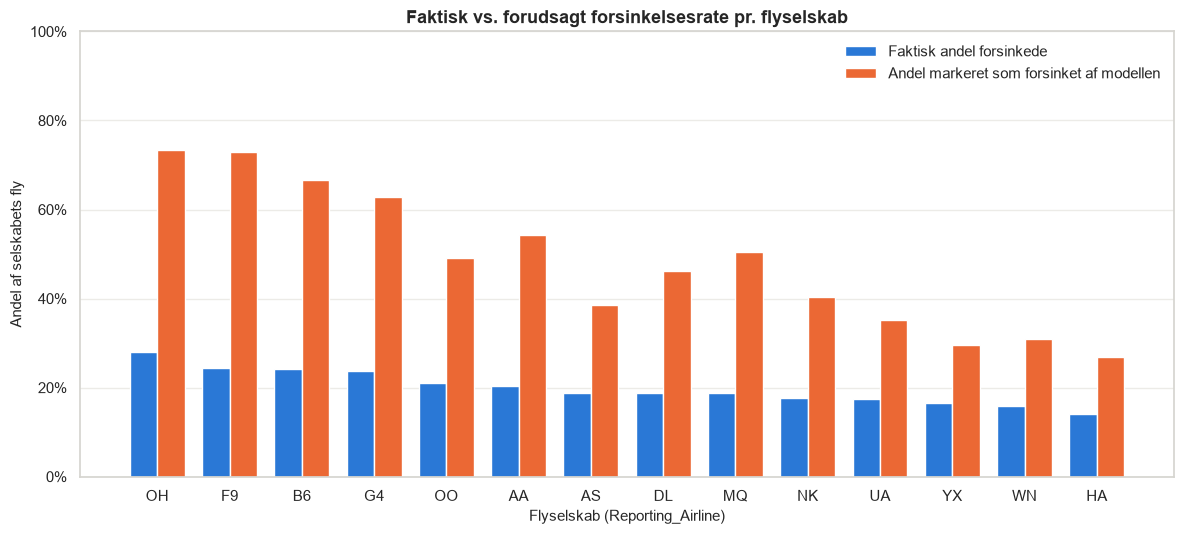

Overestimering (forudsagt / faktisk rate):
Airline
F9    2.98
B6    2.76
MQ    2.69
AA    2.67
G4    2.64
OH    2.63
DL    2.46
OO    2.35
NK    2.30
AS    2.06
UA    2.02
WN    1.96
HA    1.92
YX    1.78


In [94]:
plot_df = airline_metrics.sort_values("Faktisk rate", ascending=False)
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(x - width / 2, plot_df["Faktisk rate"], width, color="#2a78d6", label="Faktisk andel forsinkede")
ax.bar(x + width / 2, plot_df["Forudsagt rate"], width, color="#eb6834", label="Andel markeret som forsinket af modellen")

ax.set_title("Faktisk vs. forudsagt forsinkelsesrate pr. flyselskab")
ax.set_xlabel("Flyselskab (Reporting_Airline)")
ax.set_ylabel("Andel af selskabets fly")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print("Overestimering (forudsagt / faktisk rate):")
print((plot_df["Forudsagt rate"] / plot_df["Faktisk rate"]).round(2).sort_values(ascending=False).to_string())

### 8.5 Diskussion

*(Tallene er fra en testkørsel med Logistic Regression v2. Små afvigelser kan forekomme.)*

#### Er modellen fair over for passagererne?

**Nej, ikke hvis fairness betyder lige god varsling.** Recall varierer fra ca. **84 % hos OH** (PSA Airlines) til ca. **38 % hos HA** (Hawaiian). En passager hos OH får varsel om 5 ud af 6 forsinkelser. En passager hos HA, YX, AS, UA eller WN får varsel om under halvdelen.

**Hvem rammes?** De selskaber, der i gennemsnit er *mest punktlige*. Mønsteret er systematisk: recall følger tæt selskabets faktiske forsinkelsesrate (de fire mest forsinkede selskaber har alle recall ≥ 78 %, de fem mest punktlige ≤ 55 %). Modellen har lært, at "OH, F9 og B6 er ofte forsinkede", og markerer derfor mange af deres fly. Hos punktlige selskaber skal der mere til, før et fly markeres, og derfor overses deres forsinkelser oftere.

Konsekvensen er størst i absolutte tal hos **Southwest (WN)**. Det er det største selskab (ca. 20 % af test-sættet) med recall på ca. 48 %, og det giver ca. 5.000 oversete forsinkelser alene i test-sættet. Det er flere end hos noget andet selskab.

**Er det acceptabelt?** Det afhænger af, hvad advarslen bruges til:
- Hvis passageren blot får en "heads-up", er skaden ved en overset forsinkelse begrænset, og forskellen er måske acceptabel.
- Hvis advarslen bruges til at træffe beslutninger (fx om man skal nå et forbindelsesfly eller booke om), får passagerer hos punktlige selskaber systematisk et ringere beslutningsgrundlag. Det er uden at de selv har valgt det, og uden at de ved det.

En afbødning kunne være **separate beslutningsgrænser pr. selskab**, så recall bliver ens. Prisen er flere falske alarmer hos de punktlige selskaber.

#### Hvad hvis modellen blev brugt til at sanktionere flyselskaber?

Her bliver problemet alvorligere. Modellen **overestimerer forsinkelser for alle selskaber**, fordi `class_weight="balanced"` flytter beslutningsgrænsen. Men overestimeringen er skævt fordelt:
- F9 (Frontier) har ca. 25 % faktiske forsinkelser, men modellen markerer ca. **73 %** af deres fly (ca. 3 × for meget).
- WN har ca. 16 % faktiske forsinkelser, og modellen markerer ca. 31 % (ca. 2 ×).
- **FPR** viser det tydeligst: ca. 70 % af F9's og OH's *rettidige* fly markeres som forsinkede, mod ca. 27 % hos WN og YX. Et punktligt fly hos Frontier bliver altså ca. 2,5 gange så ofte "beskyldt" for at være forsinket som et punktligt fly hos Southwest.

At straffe selskaber ud fra modellens forudsigelser ville derfor være **ufair af to konkrete grunde**:
1. **Cirkulær logik:** Modellen bruger selskabets identitet (dummy-kolonner og `DepHour_airline_delay_rate`) som feature. Et selskab, der *historisk* har været forsinket, bliver forudsagt forsinket, også når det flyver til tiden. Et selskab, der forbedrer sig, ville stadig blive straffet, indtil modellen trænes igen.
2. **Ulige fejlrater:** Sanktionen ville ramme selskaber med høj FPR uforholdsmæssigt hårdt for forsinkelser, der aldrig skete.

Sanktioner bør bygge på **faktiske, observerede forsinkelser** og ikke på forudsigelser. En prædiktiv model er et værktøj til at *planlægge* ud fra risiko, ikke til at *dømme* ud fra den.

#### Relation til Barocas, Hardt & Narayanan (*Fairness and Machine Learning*)

**Group fairness** kræver, at statistiske mål er ens på tværs af grupper. Bogen skelner mellem tre kriterier:

| Kriterium | Krav | Hos os |
|---|---|---|
| **Independence** | Lige andel positive forudsigelser pr. gruppe | Ikke opfyldt: 27–73 % markeres |
| **Separation** | Lige TPR (recall) og FPR pr. gruppe | Ikke opfyldt: recall 38–84 %, FPR 25–70 % |
| **Sufficiency** | Et "forsinket"-varsel betyder det samme uanset gruppe (lige precision) | Ikke opfyldt: precision 20–32 % |

Når **base rates er forskellige** (her 14–28 % faktiske forsinkelser), kan separation og sufficiency ifølge bogen **ikke opfyldes samtidig**, undtagen for en perfekt model. Vi *må* altså vælge, hvilken type fairness der er vigtigst i den konkrete anvendelse:
- **Passager-varsling:** separation (lige recall) er mest relevant.
- **Sanktioner:** en lav og lige FPR er afgørende.

**Individual fairness** kræver i stedet, at **lignende individer behandles ens**. Tag to fly med samme rute, samme afgangstime og samme ugedag, som kun adskiller sig ved flyselskab. De får forskellige forudsigelser, fordi selskabet er en feature. Om det er *uretfærdigt*, afhænger af, om selskabet er et relevant træk for opgaven:
- **For passager-varsling** er det relevant, for selskabet påvirker reelt risikoen for forsinkelse. Forskelsbehandlingen er derfor begrundet.
- **For sanktioner** er det ikke relevant. Her skal selskabet vurderes på *sine faktiske flyvninger*, og hvis dets identitet påvirker vurderingen, er to ens flyvninger ikke behandlet ens.

#### Konklusion

Modellen er **ikke fair i group fairness-forstand**. Dens fejl er systematisk skævt fordelt, og skævheden følger selskabernes historiske forsinkelsesrate. Til passager-varsling kan det muligvis accepteres med åbenhed om begrænsningerne og eventuelt justerede grænser pr. selskab. Til sanktioner er den **uegnet**, fordi den i praksis straffer selskaber for deres historik og ikke for deres faktiske præstation.

## Step 9: Nye features og forsinkelsesårsager

Step 7 konkluderede, at modellen mangler information om **forhold på selve dagen**. I dette step:

- **Del A** tilføjer to nye features: trængsel i lufthavnen (`departures_this_hour`) og det enkelte flys historik (`tail_delay_rate`).
- **Del B** analyserer BTS' registrerede **årsager** til forsinkelser, som vi *ikke* må bruge som features.

---

## Del A: Nye features

### 9.1 Load rå-data

Vi skal bruge kolonner, som ikke er med i `cleaned_flights.csv`: `Tail_Number` (flyets registreringsnummer) og årsagskolonnerne til Del B. Vi loader kun de nødvendige kolonner fra `raw_flights.csv` for at spare hukommelse.

In [99]:
RAW_COLS = [
    "FlightDate", "Reporting_Airline", "Tail_Number", "Origin", "CRSDepTime",
    "ArrDelay", "Cancelled", "Diverted",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay",
]

raw = pd.read_csv("raw_flights.csv", usecols=RAW_COLS, low_memory=False)
raw["DepHour"] = raw["CRSDepTime"] // 100

print(f"Loaded: {raw.shape[0]:,} rækker, {raw.shape[1]} kolonner")

Loaded: 1,645,503 rækker, 14 kolonner


### 9.2 Feature: `departures_this_hour` (trængsel)

Antal **planlagte** afgange fra samme lufthavn, samme dato og samme time. En lufthavn med 60 afgange i én time er mere sårbar over for forsinkelser end en med 5.

**Hvorfor er det ikke leakage?** Afgangstider ligger i den offentlige køreplan og er kendt længe før flyvningen. Featuren bruger ingen information om *udfaldet* (forsinkelser), så vi må gerne beregne den på hele datasættet.

Vi tæller på de **rå data før rensning**, altså inklusive fly, der senere blev aflyst eller omdirigeret. De var jo også planlagt og optog kapacitet i køreplanen. At de blev aflyst, vidste man ikke på forhånd.

In [100]:
# Antal planlagte afgange pr. (lufthavn, dato, time), beregnet på den fulde køreplan
raw["departures_this_hour"] = (
    raw.groupby(["Origin", "FlightDate", "DepHour"])["DepHour"].transform("size")
)

print(raw["departures_this_hour"].describe().round(1))

count    1645503.0
mean          23.0
std           19.8
min            1.0
25%            7.0
50%           18.0
75%           33.0
max           92.0
Name: departures_this_hour, dtype: float64


### 9.3 Samme rensning og samme split som Step 7

Vi anvender præcis samme rensning som i Step 2: fjern aflyste og omdirigerede fly og rækker uden `ArrDelay`, og nulstil indekset. Rækkerne får så de samme indeks som i `cleaned_flights.csv`. Dermed kan vi genbruge **nøjagtig samme opdeling** som i Step 7:
- **`fit_df`:** 200k rækker til modeltræning
- **`encode_df`:** ca. 1,09 mio. rækker kun til target encoding
- **`test_df`:** 322k rækker til test

Det tjekker vi med `assert`s.

In [101]:
flights = (
    raw[(raw["Cancelled"] != 1) & (raw["Diverted"] != 1)]
    .dropna(subset=["ArrDelay"])
    .reset_index(drop=True)
)
flights["Delayed"] = (flights["ArrDelay"] > 15).astype(int)

# Tjek: samme rækker og samme rækkefølge som cleaned_flights.csv (brugt i Step 7)
assert len(flights) == len(df), "Antal rækker matcher ikke Step 7"
assert (flights["Delayed"].values == df["Delayed"].values).all(), "Target matcher ikke Step 7"
assert (flights["Origin"].values == df["Origin"].values).all(), "Rækkefølge matcher ikke Step 7"

# Genbrug Step 7's opdeling via indeks
flights_fit = flights.loc[fit_df.index]
flights_encode = flights.loc[encode_df.index]
flights_test = flights.loc[test_df.index]

print(f"Model-træning: {len(flights_fit):,}  |  Encoding: {len(flights_encode):,}  |  Test: {len(flights_test):,}")

Model-træning: 200,000  |  Encoding: 1,088,836  |  Test: 322,210


### 9.4 Feature: `tail_delay_rate` (flyets historik)

Hvert fly har et unikt `Tail_Number`. Nogle fly er oftere forsinkede end andre, fx fordi de flyver ruter med mange ture om dagen eller oftere har tekniske problemer. `tail_delay_rate` er andelen af forsinkede ture for flyet. Det er **target encoding**, præcis som i Step 7.

Samme regler for at undgå leakage:
- Raten beregnes **kun på `encode_df`**, altså træningsrækker, som hverken er test-data eller modellens egne træningsrækker.
- Der bruges **smoothing** (`m = 20`), så fly med få ture trækkes mod gennemsnittet.
- Fly, der ikke findes i træningsdata, får den **globale rate**.

In [102]:
TAIL_GLOBAL_RATE = flights_encode["Delayed"].mean()

# Udglattet forsinkelsesrate pr. fly, KUN på encoding-data
tail_stats = flights_encode.groupby("Tail_Number")["Delayed"].agg(["sum", "count"])
tail_rates = (tail_stats["sum"] + SMOOTHING * TAIL_GLOBAL_RATE) / (tail_stats["count"] + SMOOTHING)


def tail_delay_rate(data):
    """Map flyets historiske forsinkelsesrate; ukendte fly får gennemsnittet."""
    return data["Tail_Number"].map(tail_rates).fillna(TAIL_GLOBAL_RATE)


unseen = ~flights_test["Tail_Number"].isin(tail_rates.index)
print(f"Fly (tail numbers) i encoding-data: {len(tail_rates):,}")
print(f"Test-fly uden historik (får gennemsnit): {unseen.sum():,} ({unseen.mean():.3%})")

Fly (tail numbers) i encoding-data: 5,779
Test-fly uden historik (får gennemsnit): 2 (0.001%)


### 9.5 Byg v3-feature-sættet

Vi tager Step 7's feature-sæt (`X_train_v2` / `X_test_v2`) og tilføjer de to nye kolonner. Indeksene er de samme, så alt passer sammen række for række.

In [103]:
X_train_v3 = X_train_v2.assign(
    departures_this_hour=flights_fit["departures_this_hour"],
    tail_delay_rate=tail_delay_rate(flights_fit),
)
X_test_v3 = X_test_v2.assign(
    departures_this_hour=flights_test["departures_this_hour"],
    tail_delay_rate=tail_delay_rate(flights_test),
)

print("Train:", X_train_v3.shape, " Test:", X_test_v3.shape)
display(X_train_v3[["Origin_delay_rate", "DepHour_airline_delay_rate",
                    "departures_this_hour", "tail_delay_rate"]].describe().round(3))

Train: (200000, 23)  Test: (322210, 23)


,Origin_delay_rate,DepHour_airline_delay_rate,departures_this_hour,tail_delay_rate
count,200000.000,200000.000,200000.000,200000.000
mean,0.191,0.191,23.016,0.190
std,0.036,0.059,19.770,0.050
min,0.075,0.041,1.000,0.067
25%,0.163,0.152,7.000,0.156
50%,0.198,0.197,18.000,0.184
75%,0.217,0.226,33.000,0.219
max,0.425,0.449,92.000,0.437


### 9.6 Træn modellerne

Samme to modeller og indstillinger som i Step 7. Kun features er ændret.

In [104]:
v3_results = []  # metrics for v3-modellerne
v3_probas = {}   # sandsynligheder til ROC-kurver


def evaluate_v3(name, model, X_tr, X_te):
    """Træn model på givne features og evaluer på test-sættet."""
    start = time.time()
    model.fit(X_tr, y_train_v2)
    y_proba = model.predict_proba(X_te)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test_v2, y_pred),
        "Precision": precision_score(y_test_v2, y_pred, zero_division=0),
        "Recall": recall_score(y_test_v2, y_pred),
        "F1-score": f1_score(y_test_v2, y_pred),
        "ROC-AUC": roc_auc_score(y_test_v2, y_proba),
        "Tid (s)": time.time() - start,
    }
    v3_results.append(metrics)
    v3_probas[name] = y_proba
    print(f"{name:<45} F1 = {metrics['F1-score']:.4f}   ROC-AUC = {metrics['ROC-AUC']:.4f}")


evaluate_v3(
    "Decision Tree v3 (balanced, depth=10)",
    DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
    X_train_v3, X_test_v3,
)
evaluate_v3(
    "Logistic Regression v3 (balanced)",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    X_train_v3, X_test_v3,
)

Decision Tree v3 (balanced, depth=10)         F1 = 0.3583   ROC-AUC = 0.6259
Logistic Regression v3 (balanced)             F1 = 0.3620   ROC-AUC = 0.6364


### 9.7 Robusthedstjek: lækker `tail_delay_rate` information fra samme dag?

Vores train/test split er **tilfældigt** og ikke tidsbaseret. Hvis et fly flyver 5 ture på en dag, kan tur 1, 2 og 5 havne i træningsdata og tur 3 i test-data. Når vi beregner `tail_delay_rate` for tur 3, indgår tur 5 så i gennemsnittet. **Tur 5 ligger efter tur 3 og ville ikke være kendt på forudsigelsestidspunktet.** Forsinkelser forplanter sig netop gennem dagen for det samme fly, så de andre ture samme dag siger meget om, hvordan tur 3 går.

Det er det, Kapoor & Narayanan (2023) kalder **temporal leakage**: modellen får adgang til information fra fremtiden i forhold til forudsigelsen.

For at måle effekten beregner vi en variant af `tail_delay_rate`, der **udelader flyets ture på samme dato**. Falder resultatet, var en del af forbedringen leakage og ikke reel forudsigelseskraft.

In [105]:
# Sum og antal pr. fly pr. dato (på encoding-data), så de kan trækkes fra totalen
tail_day_stats = flights_encode.groupby(["Tail_Number", "FlightDate"])["Delayed"].agg(["sum", "count"])


def tail_delay_rate_excl_same_day(data):
    """Flyets forsinkelsesrate beregnet UDEN flyets andre ture samme dag."""
    keys = data[["Tail_Number", "FlightDate"]]
    total = keys.join(tail_stats, on="Tail_Number")[["sum", "count"]].fillna(0)
    same_day = keys.join(tail_day_stats, on=["Tail_Number", "FlightDate"])[["sum", "count"]].fillna(0)
    delayed = total["sum"] - same_day["sum"]
    count = total["count"] - same_day["count"]
    return (delayed + SMOOTHING * TAIL_GLOBAL_RATE) / (count + SMOOTHING)


X_train_v3_strict = X_train_v3.assign(tail_delay_rate=tail_delay_rate_excl_same_day(flights_fit))
X_test_v3_strict = X_test_v3.assign(tail_delay_rate=tail_delay_rate_excl_same_day(flights_test))

evaluate_v3(
    "Decision Tree v3-strict (uden samme dag)",
    DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42),
    X_train_v3_strict, X_test_v3_strict,
)
evaluate_v3(
    "Logistic Regression v3-strict (uden samme dag)",
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    X_train_v3_strict, X_test_v3_strict,
)

Decision Tree v3-strict (uden samme dag)      F1 = 0.3559   ROC-AUC = 0.6252
Logistic Regression v3-strict (uden samme dag) F1 = 0.3581   ROC-AUC = 0.6312


### 9.8 Sammenligning med Step 7

In [106]:
comparison_v3 = (
    pd.concat([
        pd.DataFrame(v2_results).assign(Version="Step 7: lufthavns-features"),
        pd.DataFrame(v3_results[:2]).assign(Version="Step 9: + trængsel + tail"),
        pd.DataFrame(v3_results[2:]).assign(Version="Step 9: strict (uden samme dag)"),
    ])
    .set_index(["Version", "Model"])
    [["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Tid (s)"]]
    .round({"Accuracy": 4, "Precision": 4, "Recall": 4, "F1-score": 4, "ROC-AUC": 4, "Tid (s)": 1})
)
display(comparison_v3)

Accuracy  \
Version                         Model                                                      
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)             0.5839   
                                Logistic Regression v2 (balanced)                 0.5886   
Step 9: + trængsel + tail       Decision Tree v3 (balanced, depth=10)             0.5860   
                                Logistic Regression v3 (balanced)                 0.5955   
Step 9: strict (uden samme dag) Decision Tree v3-strict (uden samme dag)          0.5604   
                                Logistic Regression v3-strict (uden samme dag)    0.5910   

                                                                                Precision  \
Version                         Model                                                       
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)              0.2523   
                                Logistic Regression v2 (balanced)                  0.2537   
Step 9: + trængsel + tail       Decision Tree v3 (balanced, depth=10)              0.2543   
                                Logistic Regression v3 (balanced)                  0.2588   
Step 9: strict (uden samme dag) Decision Tree v3-strict (uden samme dag)           0.2469   
                                Logistic Regression v3-strict (uden samme dag)     0.2555   

                                                                                Recall  \
Version                         Model                                                    
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)           0.6023   
                                Logistic Regression v2 (balanced)               0.5965   
Step 9: + trængsel + tail       Decision Tree v3 (balanced, depth=10)           0.6064   
                                Logistic Regression v3 (balanced)               0.6020   
Step 9: strict (uden samme dag) Decision Tree v3-strict (uden samme dag)        0.6372   
                                Logistic Regression v3-strict (uden samme dag)  0.5984   

                                                                                F1-score  \
Version                         Model                                                      
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)             0.3556   
                                Logistic Regression v2 (balanced)                 0.3560   
Step 9: + trængsel + tail       Decision Tree v3 (balanced, depth=10)             0.3583   
                                Logistic Regression v3 (balanced)                 0.3620   
Step 9: strict (uden samme dag) Decision Tree v3-strict (uden samme dag)          0.3559   
                                Logistic Regression v3-strict (uden samme dag)    0.3581   

                                                                                ROC-AUC  \
Version                         Model                                                     
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)            0.6277   
                                Logistic Regression v2 (balanced)                0.6293   
Step 9: + trængsel + tail       Decision Tree v3 (balanced, depth=10)            0.6259   
                                Logistic Regression v3 (balanced)                0.6364   
Step 9: strict (uden samme dag) Decision Tree v3-strict (uden samme dag)         0.6252   
                                Logistic Regression v3-strict (uden samme dag)   0.6312   

                                                                                Tid (s)  
Version                         Model                                                    
Step 7: lufthavns-features      Decision Tree v2 (balanced, depth=10)               0.7  
                                Logistic Regression v2 (balanced)                   0.2  
Step 9: + trængsel + tail       Decision Tree v3 (b

### 9.9 ROC-kurver: Step 7 vs. Step 9

Farve = modeltype. **Stiplet** = Step 7, **fuldt optrukket** = Step 9, **prikket** = Step 9 strict.

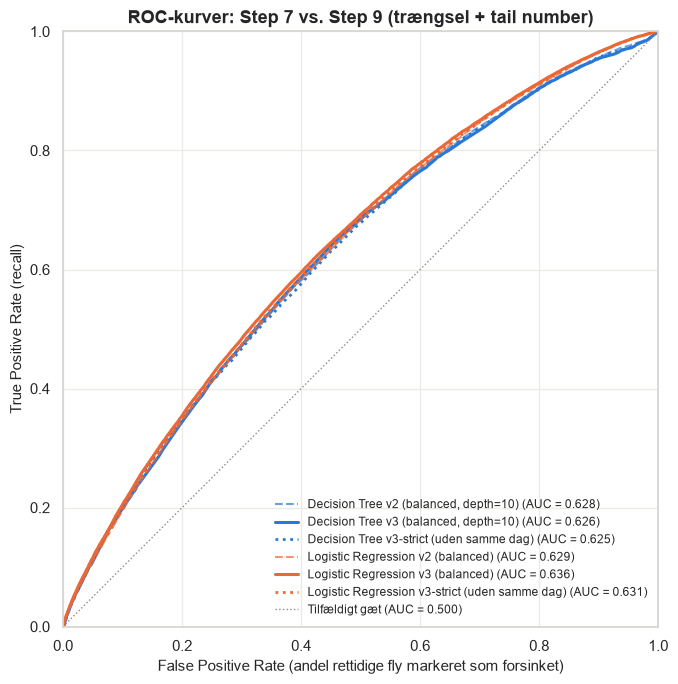

In [107]:
STYLES = {
    "v2": dict(linestyle="--", linewidth=1.5, alpha=0.7),       # Step 7
    "v3 (": dict(linestyle="-", linewidth=2.2),                 # Step 9
    "v3-strict": dict(linestyle=":", linewidth=2.0),            # Step 9 strict
}

fig, ax = plt.subplots(figsize=(8, 7))
all_probas = {**v2_probas, **v3_probas}

for model_type, color in MODEL_COLORS.items():
    for tag, style in STYLES.items():
        for name, y_proba in all_probas.items():
            if name.startswith(model_type) and tag in name:
                fpr, tpr, _ = roc_curve(y_test_v2, y_proba)
                ax.plot(fpr, tpr, color=color, **style,
                        label=f"{name} (AUC = {roc_auc_score(y_test_v2, y_proba):.3f})")

ax.plot([0, 1], [0, 1], color="#8a8984", linestyle=":", linewidth=1,
        label="Tilfældigt gæt (AUC = 0.500)")

ax.set_title("ROC-kurver: Step 7 vs. Step 9 (trængsel + tail number)")
ax.set_xlabel("False Positive Rate (andel rettidige fly markeret som forsinket)")
ax.set_ylabel("True Positive Rate (recall)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(frameon=False, loc="lower right", fontsize=8.5)
plt.tight_layout()
plt.show()

### 9.10 Fortolkning af Del A

*(Tallene er fra en testkørsel. Små afvigelser kan forekomme.)*

| Model | ROC-AUC Step 7 | Step 9 | Step 9 strict |
|---|---|---|---|
| Logistic Regression | 0,629 | **0,636** | 0,631 |
| Decision Tree (depth=10) | 0,628 | 0,626 | 0,625 |

- **`departures_this_hour` tilføjer næsten intet.** Trængsel pr. time ser ikke ud til at forklare forsinkelser ud over det, lufthavnens og tidspunktets gennemsnitsrate allerede fanger. Travle lufthavne og travle timer er i forvejen "kendt" af `Origin_delay_rate` og `DepHour`.
- **`tail_delay_rate` forbedrer Logistic Regression en smule** (+0,007 AUC). Decision Tree forbedres ikke. Med `max_depth=10` bruger træet sine splits på de eksisterende features.
- **Robusthedstjekket viser, at ca. 3/4 af gevinsten var temporal leakage.** Når flyets ture samme dag udelades, falder Logistic Regressions AUC fra 0,636 til 0,631. Kun ca. +0,002 over Step 7 er *reel* forudsigelseskraft. **Step 9 strict er det ærlige resultat.**

**Læring:** Features, der er target encodings af meget specifikke enheder (her ca. 5.800 individuelle fly), er særligt udsatte for leakage, når train og test ikke er adskilt i tid. En korrekt opsætning til produktion ville være et **tidsbaseret split**: træn på januar–februar, test på marts, og beregn alle rater kun på data *før* forudsigelsestidspunktet.

---

## Del B: Forsinkelsesårsager

### 9.11 Hvorfor må årsagskolonnerne ikke bruges som features?

BTS registrerer for hver forsinket flyvning (≥ 15 min), hvor mange minutter der skyldes hver af fem årsager:

| Kolonne | Årsag |
|---|---|
| `CarrierDelay` | Selskabets eget ansvar: vedligehold, besætning, bagage, tankning |
| `WeatherDelay` | Ekstremt vejr (fx snestorm, orkan) |
| `NASDelay` | Det nationale luftrumssystem: flyveledelse, trængsel, ikke-ekstremt vejr |
| `SecurityDelay` | Sikkerhed: evakuering, lange sikkerhedskøer |
| `LateAircraftDelay` | Flyet ankom for sent fra sin forrige tur (kaskade) |

Som **features** er de et klart eksempel på det, Kapoor & Narayanan kalder **brug af ikke-legitime features** (*"model uses non-legitimate features"*):
1. **De findes kun efter flyvningen.** Årsagerne registreres, når flyet er landet, så de er ikke tilgængelige på forudsigelsestidspunktet.
2. **De er en direkte kode for target.** Kolonnerne udfyldes kun for fly med ankomstforsinkelse på mindst 15 minutter. En model ville hurtigt lære, at "CarrierDelay > 0 ⇒ forsinket", og få nær-perfekte scores, som er fuldstændig værdiløse i praksis.

Som **analyse** er de til gengæld meget værdifulde. De fortæller os, *hvorfor* fly bliver forsinket, og dermed hvilke features der mangler i vores model.

### 9.12 Gennemsnitlig fordeling af forsinkelsesårsager

Forsinkede fly: 307,125
Gennemsnitlig forsinkelse: 73.5 minutter

                         Gns. minutter   Andel
Forsinket fly (kaskade)           27.3  37.2 %
Flyselskab                        25.2  34.3 %
Luftrum (NAS)                     15.7  21.3 %
Ekstremt vejr                      5.2   7.1 %
Sikkerhed                          0.1   0.1 %


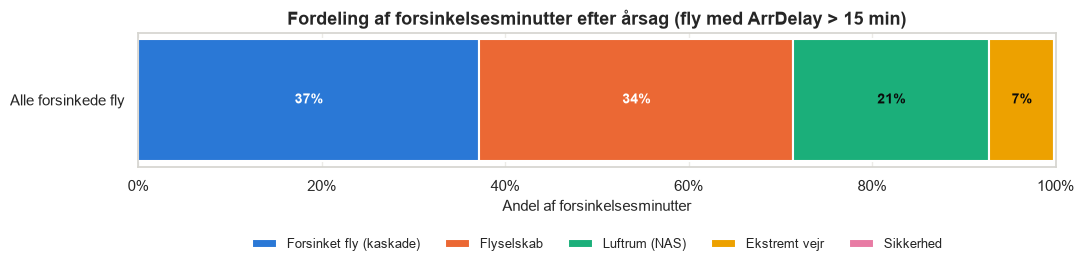

In [108]:
CAUSES = ["LateAircraftDelay", "CarrierDelay", "NASDelay", "WeatherDelay", "SecurityDelay"]
CAUSE_LABELS = {
    "LateAircraftDelay": "Forsinket fly (kaskade)",
    "CarrierDelay": "Flyselskab",
    "NASDelay": "Luftrum (NAS)",
    "WeatherDelay": "Ekstremt vejr",
    "SecurityDelay": "Sikkerhed",
}
CAUSE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
# Mørk tekst på lyse segmenter, hvid på mørke
CAUSE_TEXT = ["white", "white", "#0b0b0b", "#0b0b0b", "#0b0b0b"]

# Kun forsinkede fly (> 15 min), som i vores target
delayed_flights = flights[flights["ArrDelay"] > 15]

mean_minutes = delayed_flights[CAUSES].mean()
shares = mean_minutes / mean_minutes.sum()

print(f"Forsinkede fly: {len(delayed_flights):,}")
print(f"Gennemsnitlig forsinkelse: {mean_minutes.sum():.1f} minutter\n")
print(pd.DataFrame({
    "Gns. minutter": mean_minutes.round(1),
    "Andel": (shares * 100).round(1).astype(str) + " %",
}).rename(index=CAUSE_LABELS))


def stacked_cause_bars(ax, share_table, legend_y=-0.18):
    """Vandret 100 %-stacked bar pr. række i share_table (kolonner = CAUSES)."""
    left = np.zeros(len(share_table))
    for cause, color, text_color in zip(CAUSES, CAUSE_COLORS, CAUSE_TEXT):
        values = share_table[cause].values
        ax.barh(share_table.index, values, left=left, color=color,
                edgecolor="white", linewidth=1.5, label=CAUSE_LABELS[cause])
        # Direkte labels på segmenter der er store nok til at kunne læses
        for i, (v, l) in enumerate(zip(values, left)):
            if v >= 0.06:
                ax.text(l + v / 2, i, f"{v:.0%}", ha="center", va="center",
                        color=text_color, fontsize=10, fontweight="bold")
        left += values
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis="y", visible=False)
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, legend_y), ncol=5, fontsize=9)


fig, ax = plt.subplots(figsize=(11, 3.4))
stacked_cause_bars(ax, shares.to_frame("Alle forsinkede fly").T, legend_y=-0.45)
ax.set_title("Fordeling af forsinkelsesminutter efter årsag (fly med ArrDelay > 15 min)")
ax.set_xlabel("Andel af forsinkelsesminutter")
plt.tight_layout()
plt.show()

### 9.13 Årsager pr. flyselskab (top 5 mest forsinkede)

Vi vælger de 5 selskaber med den højeste andel forsinkede fly og viser fordelingen af årsager for hver. Til sammenligning vises "Alle selskaber" nederst.

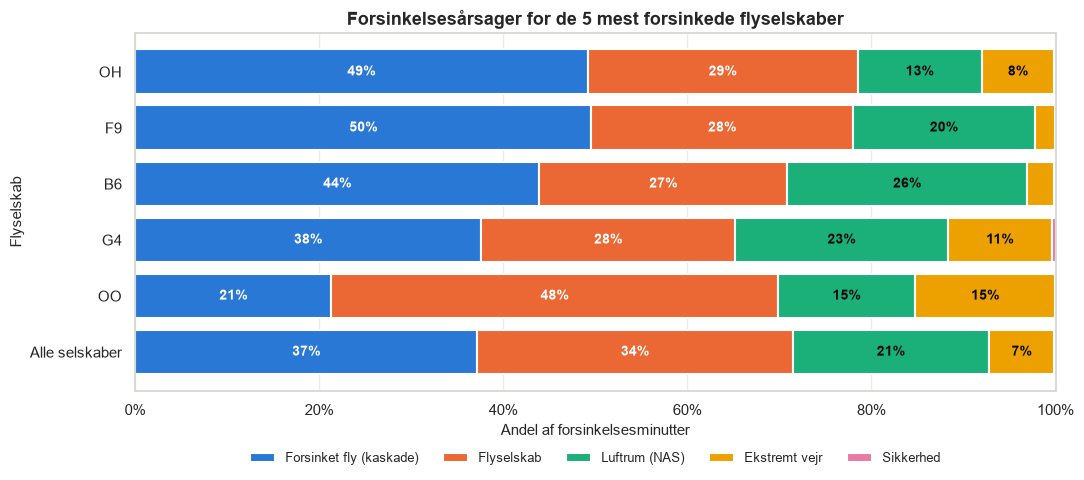

Gennemsnitlige forsinkelsesminutter pr. årsag (forsinkede fly):


,Forsinket fly (kaskade),Flyselskab,Luftrum (NAS),Ekstremt vejr,Sikkerhed
Reporting_Airline,,,,,
OH,44.8,26.7,12.3,7.2,0.1
F9,40.6,23.3,16.2,1.8,0.0
B6,32.7,20.1,19.4,2.2,0.1
G4,34.3,25.2,21.1,10.4,0.3
OO,17.9,40.6,12.6,12.7,0.1


In [109]:
# Top 5 selskaber efter andel forsinkede fly
top5 = flights.groupby("Reporting_Airline")["Delayed"].mean().nlargest(5).index

airline_minutes = delayed_flights[delayed_flights["Reporting_Airline"].isin(top5)].groupby("Reporting_Airline")[CAUSES].mean()
airline_shares = airline_minutes.div(airline_minutes.sum(axis=1), axis=0).loc[top5]

# Tilføj "Alle selskaber" som reference og vend rækkefølgen, så den mest forsinkede står øverst
airline_shares.loc["Alle selskaber"] = shares
airline_shares = airline_shares.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
stacked_cause_bars(ax, airline_shares, legend_y=-0.14)
ax.set_title("Forsinkelsesårsager for de 5 mest forsinkede flyselskaber")
ax.set_xlabel("Andel af forsinkelsesminutter")
ax.set_ylabel("Flyselskab")
plt.tight_layout()
plt.show()

print("Gennemsnitlige forsinkelsesminutter pr. årsag (forsinkede fly):")
display(airline_minutes.loc[top5].rename(columns=CAUSE_LABELS).round(1))

### 9.14 Fortolkning af Del B

*(Tallene er fra en testkørsel.)*

**Samlet billede (gennemsnitlig forsinkelse ca. 73 minutter for forsinkede fly):**
- **Forsinket fly / kaskade (ca. 37 %)** er den største årsag. En forsinkelse tidligt på dagen forplanter sig til flyets næste ture. Det forklarer mønsteret i EDA'en (Step 4), hvor forsinkelsesraten stiger jævnt hen over dagen.
- **Flyselskabet selv (ca. 34 %)** står for næsten lige så meget: besætning, vedligehold og ground handling.
- **Luftrum/NAS (ca. 21 %)** dækker flyveledelse, trængsel og almindeligt dårligt vejr.
- **Ekstremt vejr (ca. 7 %)** er mindre, end man skulle tro, fordi det meste vejr registreres under NAS.
- **Sikkerhed (< 1 %)** er ubetydelig.

**Pr. flyselskab er der to forskellige profiler:**
- **OH (PSA) og F9 (Frontier)** har ca. halvdelen af deres forsinkelsesminutter fra **kaskader**. Deres fly flyver mange korte ture tæt efter hinanden, så én forsinkelse rammer resten af dagen. Deres problem er primært *planlægning og buffertid*.
- **OO (SkyWest)** skiller sig ud: kun ca. 21 % kaskade, men ca. **48 % selskabs-årsager** og 15 % ekstremt vejr. SkyWest flyver mange regionale ruter i bjergområder og i det nordlige USA om vinteren, og dets forsinkelser er i højere grad *operationelle*.
- Samme forsinkelsesrate kan altså have vidt forskellige årsager. Det har betydning for fairness-diskussionen i Step 8: et selskab, der forsinkes af vejret, har mindre ansvar end et, der forsinkes af egen drift.

**Hvad betyder det for modellen?**
- Den største årsag, **kaskade-forsinkelser**, kræver at vide, om *flyets forrige tur* er forsinket. Det er præcis den information, vi *ikke* har, og som `tail_delay_rate` kun groft tilnærmer (og delvist lækker, jf. 9.7). En legitim feature ville være **forsinkelsen på flyets forrige tur samme dag**, kendt på forudsigelsestidspunktet. Den kan beregnes ud fra `Tail_Number`, `FlightDate` og afgangstider, men kræver omhyggelig håndtering af tid for ikke at lække.
- **Selskabs-årsager** fanges delvist af vores flyselskabs-features. Det forklarer, hvorfor flyselskab var en af de stærkeste features.
- **Luftrum og vejr** kræver eksterne data (vejrudsigter, FAA-meldinger), som ikke er i BTS-datasættet.

Årsagsanalysen er altså ikke en feature, men et **kompas**. Den peger på, at den største forbedring ligger i at modellere kaskade-forsinkelser korrekt.